<!-- Nivel 2: Subtítulo -->
<h2 style="color:#9D2449; font-family:'Montserrat', sans-serif; font-size:42px; font-weight:700; margin-top:25px; margin-bottom:12px;">
Índice de Esfuerzo Ciudadano
</h2>

<!-- Nivel 4: Subsección -->
<h4 style="color:#B38E5D; font-family:'Montserrat', sans-serif; font-size:22px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Estimación del esfuerzo en trámites y servicios estatales.
</h4>

Se establece una metodología cuantitativa para evaluar la eficiencia administrativa mediante la integración y depuración de registros gubernamentales utilizando técnicas de fuzzy matching. A través de un análisis estadístico avanzado —empleando ECDF, KDE y Boxplots—, se determinaron umbrales objetivos para normalizar la heterogeneidad de los datos, permitiendo la creación de subíndices robustos de tiempo, requisitos, formatos y costos. Como resultado, se consolidó el Índice de Esfuerzo Ciudadano, una métrica compuesta que jerarquiza la carga burocrática desde la perspectiva del usuario, ponderando variables críticas como tiempo (35%), digitalización (20%), requisitos (20%), formatos (15%) y costo (10%). Finalmente, la implementación del algoritmo de agrupamiento K-Means permitió segmentar los trámites en cuatro perfiles operativos: Burocracia Pesada, Recaudación Eficiente, Deficiencia Digital y Servicios Gratuitos Funcionales, proporcionando una hoja de ruta estratégica para focalizar los esfuerzos de simplificación y transformación digital donde mayor es su impacto.


<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Base de datos
</h4>

Se crea el docuemento Effor_index.xlsx cruzando información de diferentes bases de datos creadas a partir de los archivos proporcionados, se agregan las siguientes columnas a su estructura. 

1. $\texttt{Idtram}$
2. $\texttt{Tramite}$
3. $\texttt{Secretaria}$
4. $\texttt{Dependencia}$
5. $\texttt{Domicilio}$
6. $\texttt{TraPersona}$
7. $\texttt{Tiempo\_en\_minutos}$
8. $\texttt{N\_FORMATOS\_FINAL}$
9. $\texttt{CONTEO\_NETO}$
10. $\texttt{nivel\_digitalizacion}$
11. $\texttt{TraResolucionesFavorables}$
12. $\texttt{TraResolucionesNegativas}$
13. $\texttt{Porcentaje\_Efectividad}$
14. $\texttt{TraCosto}$

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os

ruta_base_fonts = '/Users/gonza/Downloads/Montserrat-2/static'
ruta_bold = os.path.join(ruta_base_fonts, 'Montserrat-Bold.ttf')
ruta_reg  = os.path.join(ruta_base_fonts, 'Montserrat-Regular.ttf')
ruta_semi = os.path.join(ruta_base_fonts, 'Montserrat-SemiBold.ttf')

for ruta in [ruta_bold, ruta_reg, ruta_semi]:
    if os.path.exists(ruta):
        fm.fontManager.addfont(ruta)

if os.path.exists(ruta_bold):
    prop_bold = fm.FontProperties(fname=ruta_bold)
    prop_reg  = fm.FontProperties(fname=ruta_reg)
    prop_semi = fm.FontProperties(fname=ruta_semi)
    plt.rcParams['font.family'] = 'Montserrat'
    print("✅ Fuentes Montserrat cargadas.")
else:
    prop_bold = prop_reg = prop_semi = None
    print("⚠️  Montserrat no encontrada, usando fuente por defecto.")

plt.rcParams.update({
    'font.weight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'text.color': '#000000',
    'axes.labelcolor': '#000000',
    'xtick.color': '#000000',
    'ytick.color': '#000000',
    'figure.dpi': 300
})

guinda_gob = '#9D2449'
verde_gob  = '#235B4E'
negro_puro = '#000000'

print("✅ Entorno de gráficos configurado.")


In [ ]:
import io, requests
import pandas as pd

# ── Carga de archivos desde GitHub ─────────────────────────────────────────

# Base_Final
url_base = 'https://raw.githubusercontent.com/gonza98kg/Tramites-y-servicios/combinacion-lineal-ponderada/Base_Final.csv'
df_base  = pd.read_csv(url_base)

# Effor_index_MASTER — hoja principal de trabajo
url_master = 'https://raw.githubusercontent.com/gonza98kg/Tramites-y-servicios/combinacion-lineal-ponderada/Effor_index_MASTER.xlsx'
r          = requests.get(url_master)
df         = pd.read_excel(io.BytesIO(r.content), sheet_name='Effor_index')

print(f'Base_Final:          {df_base.shape[0]} filas, {df_base.shape[1]} columnas')
print(f'Effor_index_MASTER:  {df.shape[0]} filas, {df.shape[1]} columnas')


Se buscan trámites repetidos que pudieran haberse filtrado en el cruce de datos para eliminarlos. Así como un conteo de cuántos trámites por secretaría se tienen.

In [ ]:
# 1. Idtram repetidos
conteos   = df["Idtram"].value_counts()
duplicados = conteos[conteos > 1]

print("Valores repetidos en la columna 'Idtram':")
print(duplicados)

# 2. Conteo por Secretaría
conteo = df["Secretaria"].value_counts()

print("\nConteo por Secretaría:")
print(conteo)

total_tramites    = len(df)
total_secretarias = df["Secretaria"].nunique()

print("\nTotal de trámites en la base:", total_tramites)
print("Total de secretarías distintas:", total_secretarias)



<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Normalización Multidimensional de Trámites
</h4>

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Sub-índice de Tiempo
</h4>

Los tiempos registrados en los trámites se encontraban en unidades diferentes, tales como minutos, horas, días y meses. Para que el análisis fuera matemáticamente coherente, se transformaron todos los datos a la unidad base de minutos. Debido al rango extremo de la variable del tiempo, se utilizó una escala logarítmica para representar la ECDF de esta variable, permitiendo un mejor manejo en la información. Se aplicó un KDE para estimar la función densidad de probabilidad de dicha variable, encontrando una distribución bimodal, donde la población A fue catalogada de primera instancia como trámites rápidos y la población B como trámites lentos. Se utilizó la topología de la *pdf* para mediante el cálculo de máximos y mínimos se definieran los siguientes umbrales para categorizar a la población, así como los valores para su normalización

1. *Rápidos:* $0<t<295\; \rm{min.}$ Un aproximado de entre 0 a 4.9 hrs. Puntaje de 0 a 25
2. *Lentos:* $295<t<9357 \; \rm{min.}$ Un aproximado de entre 4.9 hrs a 6.5 días. Puntaje de 26 a 70
3. *Críticos:* $9357<t<238115\;\rm{min.}$ Un aproximado de entre 6.5 días a 165 días. Puntaje de 71 a 100
4. *Outliers:* $t>238115\;\rm{min.}$ Mayores a 165 días. (Correspondientes al 2.7% de la población). Puntaje de 100

Para asignar los valores de normalización se utiliza la siguiente función a tramos $T(t)$

$$
T(t)=
\begin{cases}
\frac{t}{295}\times 25&: 0 < t < 295 \\
\frac{t-295}{9357-295}\times(70-25)+25&:  295 < t < 9357\\
\frac{t-9357}{238115-9357}+(100-70)+70&:  9357 < t < 238115\\
100&: t> 238115
\end{cases}
$$


Esta ponderación se basa en intentar definir que tan rapido sube el puntaje por cada unidad de tiempo agregada, tomando como referencia la ecuación $y=mt+b$ donde la pendiente $m=\frac{1}{x_{\rm{max}}-x_{\rm{min}}}$

**¿Por qué no se usa un $z$-score?**
Ya que el $z$-score se define en función del promedio y la varianza tal que $z=\frac{t-\mu}{\sigma}$, debido a la presencia de la cola correspondiente al $2.7\%$ de trámites que duran más de 3.5 meses y de la naturaleza bimodal de la *pdf*, el promedio podría no proporcionar datos correctos y por consecuencia la desviación estandar. El $z$-score funciona muy bien en distribuciones normales, lo cual no es el caso del presente análisis.

Se empleó el siguiente código para leer los datos de tiempo de la base *Effor_index*, aplicar la lógica matemática descrita anteriormente y crear la columna $\texttt{I\_Tiempo}$ en la misma base de datos.  



In [ ]:
import pandas as pd

def calcular_subindice_tiempo(t):
    if pd.isna(t) or str(t).strip() == "":
        return None
    try:
        t = float(t)
    except ValueError:
        return None
    if t < 0:
        return None
    lim_rapido  = 295
    lim_lento   = 9357
    lim_critico = 238115
    if t <= lim_rapido:
        return (t / lim_rapido) * 25
    elif t <= lim_lento:
        progreso = (t - lim_rapido) / (lim_lento - lim_rapido)
        return 25 + (progreso * 45)
    elif t <= lim_critico:
        progreso = (t - lim_lento) / (lim_critico - lim_lento)
        return 70 + (progreso * 30)
    else:
        return 100

try:
    valores_tiempo = df["Tiempo_en_minutos"].apply(calcular_subindice_tiempo)
    col_nueva = "I_Tiempo"
    if col_nueva in df.columns:
        df = df.drop(columns=[col_nueva])
    indice_columna = df.columns.get_loc("Tiempo_en_minutos") + 1
    df.insert(loc=indice_columna, column=col_nueva, value=valores_tiempo)
    print(f"Columna '{col_nueva}' generada.")
    print(df[df["Tiempo_en_minutos"].isna()][["Tramite", "Tiempo_en_minutos", "I_Tiempo"]].head())
except Exception as e:
    print(f"Error: {e}")


<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Sub-índice de Requisitos
</h4>

Dado la limpieza previa para distinguir entre requisitos, condicionantes, ruido y documentos de acreditación, se ajustó el umbral de requisitos mediante el análisis de boxplots, separando las siguientes poblaciones. 

1. 3 requisitos (Bajo)
2. 6 requisitos (Medio)
3. 11 requisitos o más (Alto). 

Donde se propone puntar de la siguiente manera. 

$$

R=\rm{min}\left(100, \frac{r}{11}\times 100\right)

$$

En resumen, se toma el número de trámites y coloca un tope en 11, es decir, la mayor puntuación será de 100 a partir de 11 requisitos en adelante, cualquier número menor se escalará sobre 11. Cada requisito agregado aporta un valor de $\frac{1}{11}\approx9.09$. Por ejemplo

1. 3 requisitos $\approx$ 27 puntos.
2. 6 requisitos $\approx$ 54 puntos
3. 11 requisitos o más $\approx$ 100 puntos. 

Se extablece la lógica matemática en este código y se crea la columna $\texttt{I\_Requisitos}$

In [ ]:
def calcular_subindice_requisitos(n):
    if pd.isna(n) or str(n).strip() == "":
        return None
    try:
        n = float(n)
    except ValueError:
        return None
    if n < 0:
        return None
    puntaje = (n / 11) * 100
    return min(puntaje, 100)

try:
    col_origen = "CONTEO_NETO"
    col_nueva  = "I_Requisitos"
    if col_origen not in df.columns:
        raise KeyError(f"No se encontró la columna '{col_origen}'.")
    valores_reqs = df[col_origen].apply(calcular_subindice_requisitos)
    if col_nueva in df.columns:
        df = df.drop(columns=[col_nueva])
    indice_columna = df.columns.get_loc(col_origen) + 1
    df.insert(loc=indice_columna, column=col_nueva, value=valores_reqs)
    print(f"Columna '{col_nueva}' agregada.")
    print(df[[col_origen, col_nueva]].head(10))
except Exception as e:
    print(f"Error: {e}")


<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Sub-índice de Formatos
</h4>

Para el caso de los formatos se aplicó una metodología similar empleando boxplots para estimar el umbral, este se encontró alrededor de 2.5 trámites, ya que se está trabajando con números enteros se redondea a 3 trámites. Si se tienen 3 trámites o más, se penaliza de una forma mayor. Por lo que también se aborda una función a trozos.

$$
F=
\begin{cases}
f\times10&: f\leq 3\\
30+(f-3)\times20&: f>3
\end{cases}
$$

Así de esta forma
1. $f=1\Rightarrow$ 10 puntos
2. $f=3\Rightarrow$ 30 puntos
3. $f=4\Rightarrow$ 50 puntos
4. $f=6\Rightarrow$ 90 puntos

Se crea la columna $\texttt{I\_Formatos}$

In [ ]:
def calcular_subindice_formatos(k):
    if pd.isna(k) or str(k).strip() == "":
        return None
    try:
        k = float(k)
    except ValueError:
        return None
    if k < 0:
        return None
    puntaje = k * 10 if k <= 3 else 30 + (k - 3) * 20
    return min(puntaje, 100)

try:
    col_origen = "N_FORMATOS_FINAL"
    col_nueva  = "I_Formatos"
    if col_origen not in df.columns:
        raise KeyError(f"No se encontró la columna '{col_origen}'.")
    valores_formatos = df[col_origen].apply(calcular_subindice_formatos)
    if col_nueva in df.columns:
        df = df.drop(columns=[col_nueva])
    indice_columna = df.columns.get_loc(col_origen) + 1
    df.insert(loc=indice_columna, column=col_nueva, value=valores_formatos)
    print(f"Columna '{col_nueva}' calculada correctamente.")
    print(df[[col_origen, col_nueva]].head(10))
except Exception as e:
    print(f"Error: {e}")


<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Sub-índice de Digitalización
</h4>

Para este caso, se cuenta, de manera previa, con una escala de tipo granular con 14 niveles que van de 1, 2, 3.1, 3.2, 3.3,..., 4.3 según las acciones que puedas hacer o no de manera digital, ver [Tab.1](#tabla_niveles), por lo que intentar cuantificar el esfuerzo para este caso se aborda de manera diferente. Se propone definir 4 variables binarias derivadas de situaciones que pueda vivir el ciudadano y que cuantifiquen el esfuerzo.

<a id="tabla_niveles"></a>
**Tabla 1:** Niveles de Digitalización

| NIVEL | DESCRIPCIÓN |
| :--- | :--- |
| **4.3** | Resolución en línea inmediata. |
| **4.2** | Firma electrónica para solicitudes y resoluciones del trámite o servicio. |
| **4.1** | Emitir resoluciones oficiales en línea. |
| **3.9** | Llenar formatos en línea, en su caso. |
| **3.8** | Agendar citas en línea. |
| **3.7** | Pago de derechos en línea. |
| **3.6** | Que el trámite o servicio presente intercambio de información con otras dependencias de manera electrónica. |
| **3.5** | Que el trámite o servicio pueda mostrar a los ciudadanos el estatus en el que se encuentra (atendido/en revisión/rechazado) por medios electrónicos. |
| **3.4** | Notificación electrónica de vencimiento de plazo de respuesta. |
| **3.3** | Notificación electrónica de plazos de prevención. |
| **3.2** | Notificación electrónica de información faltante. |
| **3.1** | Que el trámite o servicio pueda recibir solicitudes por medios electrónicos con los correspondientes acuses de recepción de datos y documentos. |
| **2** | Posibilidad de descargar formatos, en su caso. |
| **1** | Información del trámite o servicio público a través de medios electrónicos (Inscrito en el Registro de Trámites y Servicios). |

1. V = ¿El ciudadano debe trasladarse físicamente aunque tenga cita o haya pagado? 0/1      : 40%
2. A = ¿El ciudadano deber asistir a la oficina a conseguir formatos o requisitos=? 0/1     : 35%
3. I = ¿El ciudadano carece de medidas digitales para saber el estatus de sus trámites? 0/1 : 15%
4. O = ¿El ciudadano carece de herramientas de gestión de archivos? 0/1                     : 10%

De esta forma y con los niveles proporcionados se tiene.

<a id="tabla_calculo"></a>
**Tabla de Cálculo de Puntajes**

| Grupo | Componentes | Cálculo | Puntaje |
| :--- | :--- | :--- | :--- |
| **1.0** | V + O + I + A | 40 + 35 + 15 + 10 | **100** |
| **2.0** | V + O + I | 40 + 35 + 15 | **90** |
| **3.1 - 3.6** | V + O | 40 + 35 | **75** |
| **3.7 - 3.9** | V | 40 | **40** |
| **4.1 - 4.3** | — | — | **0** |

Así, mediante esta lógica se crea la columna $\texttt{I\_Digital}$



In [ ]:
def calcular_subindice_digital(texto_nivel):
    if pd.isna(texto_nivel) or str(texto_nivel).strip() == "":
        return None
    s_nivel = str(texto_nivel).replace("Nivel", "").strip()
    if s_nivel == "1":
        return 100
    elif s_nivel == "2":
        return 90
    elif s_nivel in ["3.1", "3.2", "3.3", "3.4", "3.5", "3.6"]:
        return 75
    elif s_nivel in ["3.7", "3.8", "3.9"]:
        return 40
    elif s_nivel in ["4.1", "4.2", "4.3"]:
        return 0
    else:
        return None

try:
    col_origen = "nivel_digitalizacion"
    col_nueva  = "I_Digital"
    if col_origen not in df.columns:
        disponibles = [c for c in df.columns if "nivel" in c.lower() or "digit" in c.lower()]
        raise KeyError(f"No se encontró '{col_origen}'. Disponibles: {disponibles}")
    valores_dig = df[col_origen].apply(calcular_subindice_digital)
    if col_nueva in df.columns:
        df = df.drop(columns=[col_nueva])
    indice_columna = df.columns.get_loc(col_origen) + 1
    df.insert(loc=indice_columna, column=col_nueva, value=valores_dig)
    print(f"Columna '{col_nueva}' generada.")
    print(df[[col_origen, col_nueva]].head(15))
except Exception as e:
    print(f"Error: {e}")


<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Sub-índice de Digitalización
</h4>

Como no se puede diferenciar entre un trámite barato o caro puesto que solo se cuenta con información sobre el trámite/servicio se cobra o no (por ahora), se toma una penalización por existencia y se le asignará un peso bajo.

$$
C=
\begin{cases}
0&:\rm{FALSO}\\
1&:\rm{VERDADERO}
\end{cases}
$$

In [ ]:
def calcular_subindice_costo(valor):
    if pd.isna(valor) or str(valor).strip() == "":
        return None
    s_valor = str(valor).strip().upper()
    if s_valor in ("FALSO", "FALSE"):
        return 0
    elif s_valor in ("VERDADERO", "TRUE"):
        return 100
    else:
        return None

try:
    col_origen = "TraCosto"
    col_nueva  = "I_Costo"
    if col_origen not in df.columns:
        raise KeyError(f"No se encontró la columna '{col_origen}'.")
    valores_costo = df[col_origen].apply(calcular_subindice_costo)
    if col_nueva in df.columns:
        df = df.drop(columns=[col_nueva])
    indice_columna = df.columns.get_loc(col_origen) + 1
    df.insert(loc=indice_columna, column=col_nueva, value=valores_costo)
    print(f"Columna '{col_nueva}' generada.")
    print(df[[col_origen, col_nueva]].head(10))
except Exception as e:
    print(f"Error: {e}")


<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Índice de Esfuerzo ciudadano.
</h4>

Se proponen dos índices de esfuerzo ciudadano con las siguientes ponderaciones.

**IEC_A** = $(T\times.40)+ (R\times.25)+(F\times.10)+(D\times.20)+(C\times.05)$ 
1. Tiempo: 40%
2. Requisitos: 25%
3. Formatos: 10%
4. Digitalización: 20%
5. Costo: 05%

**IEC_B** = $(T\times.35)+ (R\times.20)+(F\times.15)+(D\times.20)+(C\times.10)$ 
1. Tiempo: 35%
2. Requisitos: 20%
3. Formatos: 15%
4. Digitalización: 20%
5. Costo: 10%

Estas operaciones matemáticas se realizan en el presente código; se crean además las columnas $\texttt{IEC\_1}$ y $\texttt{IEC\_2}$ con la información adquirida. Es de mencionarse que algunos trámites y servicios contienen vacías alguna o algunas de las variables tomadas calcular este índice; se propuso en un principio asumir el peor escenario/puntuación posible para cada subíndice, sin embargo, se optó por no tomarlos en cuenta, por lo que el número de trámites analizados se redujo.

In [ ]:
# Pesos Propuesta A
w_tiempo_A, w_req_A, w_form_A, w_dig_A, w_costo_A = 0.40, 0.25, 0.10, 0.20, 0.05

# Pesos Propuesta B
w_tiempo_B, w_req_B, w_form_B, w_dig_B, w_costo_B = 0.35, 0.20, 0.15, 0.20, 0.10

# Cálculo
df['IEC_1'] = (
    df['I_Tiempo'] * w_tiempo_A + df['I_Requisitos'] * w_req_A +
    df['I_Formatos'] * w_form_A + df['I_Digital'] * w_dig_A +
    df['I_Costo'] * w_costo_A
).round(2)

df['IEC_2'] = (
    df['I_Tiempo'] * w_tiempo_B + df['I_Requisitos'] * w_req_B +
    df['I_Formatos'] * w_form_B + df['I_Digital'] * w_dig_B +
    df['I_Costo'] * w_costo_B
).round(2)

cols = list(df.columns)
columna_referencia = 'I_Costo'

if columna_referencia in cols:
    if 'IEC_1' in cols: cols.remove('IEC_1')
    if 'IEC_2' in cols: cols.remove('IEC_2')
    
    idx = cols.index(columna_referencia)
    
    cols.insert(idx + 1, 'IEC_2')
    cols.insert(idx + 1, 'IEC_1')
    
    df = df[cols]


<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Top 20 de trámites con mayor esfuerzo. (Propuestas A y B)
</h4>

Se realizó un top 20 para ambos casos de los trámites con mayor índice de esfuerzo a fin de poder realizar una primera inspección sobre posibles diferencias entre ambos y además, esbozar cuáles trámites y servicios arrojaron una mayor puntuación. 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import textwrap


ruta_base_fonts = '/Users/gonza/Downloads/Montserrat-2/static'
ruta_bold = os.path.join(ruta_base_fonts, 'Montserrat-Bold.ttf')
ruta_reg  = os.path.join(ruta_base_fonts, 'Montserrat-Regular.ttf')
ruta_semi = os.path.join(ruta_base_fonts, 'Montserrat-SemiBold.ttf')

for _f in [ruta_bold, ruta_reg, ruta_semi]:
    if os.path.exists(_f): fm.fontManager.addfont(_f)

prop_bold = fm.FontProperties(fname=ruta_bold) if os.path.exists(ruta_bold) else None
prop_reg  = fm.FontProperties(fname=ruta_reg)  if os.path.exists(ruta_reg)  else None
prop_semi = fm.FontProperties(fname=ruta_semi) if os.path.exists(ruta_semi) else None

ruta_carpeta = '/Users/gonza/Downloads/Effor_index/'
if not os.path.exists(ruta_carpeta):
    os.makedirs(ruta_carpeta)

def ajustar_nombre(texto, ancho=50):
    return "\n".join(textwrap.wrap(str(texto), width=ancho))

sns.set_theme(style="whitegrid")

guinda_gob = '#9D2449'
verde_gob = '#235B4E'
negro_puro = '#000000'

plt.rcParams.update({
    'font.family': 'Montserrat',
    'font.weight': 'bold',
    'text.color': negro_puro,
    'figure.dpi': 300
})

df_plot_A = df.sort_values(by='IEC_1', ascending=False).head(20).copy()
df_plot_A['Tramite_Visual'] = df_plot_A['Tramite'].apply(lambda x: ajustar_nombre(x))

fig_a, ax_a = plt.subplots(figsize=(12, 14))
sns.barplot(x='IEC_1', y='Tramite_Visual', data=df_plot_A, color=guinda_gob, ax=ax_a)

ax_a.set_title('Top 20 Trámites: Mayor Esfuerzo - Propuesta A', pad=20, color=guinda_gob, fontproperties=prop_bold, fontsize=18)
ax_a.set_xlabel('Índice de Esfuerzo', color=negro_puro, fontproperties=prop_bold, fontsize=14)
ax_a.set_ylabel('Trámite', color=negro_puro, fontproperties=prop_bold, fontsize=14)

ax_a.set_yticklabels(ax_a.get_yticklabels(), fontproperties=prop_bold, fontsize=10)
ax_a.set_xticklabels(ax_a.get_xticklabels(), fontproperties=prop_reg, fontsize=10)

plt.tight_layout()
plt.show()

df_plot_B = df.sort_values(by='IEC_2', ascending=False).head(20).copy()
df_plot_B['Tramite_Visual'] = df_plot_B['Tramite'].apply(lambda x: ajustar_nombre(x))

fig_b, ax_b = plt.subplots(figsize=(12, 14))
sns.barplot(x='IEC_2', y='Tramite_Visual', data=df_plot_B, color=verde_gob, ax=ax_b)

ax_b.set_title('Top 20 Trámites: Mayor Esfuerzo - Propuesta B', pad=20, color=verde_gob, fontproperties=prop_bold, fontsize=18)
ax_b.set_xlabel('Índice de Esfuerzo', color=negro_puro, fontproperties=prop_bold, fontsize=14)
ax_b.set_ylabel('Trámite', color=negro_puro, fontproperties=prop_bold, fontsize=14)

ax_b.set_yticklabels(ax_b.get_yticklabels(), fontproperties=prop_bold, fontsize=10)
ax_b.set_xticklabels(ax_b.get_xticklabels(), fontproperties=prop_reg, fontsize=10)

plt.tight_layout()
plt.show()

cols_export = ['Tramite', 'IEC_1', 'IEC_2', 'I_Tiempo', 'I_Requisitos', 'I_Formatos', 'I_Digital', 'I_Costo']
df.sort_values(by='IEC_1', ascending=False).head(15)[cols_export].to_excel(os.path.join(ruta_carpeta, 'Top15_Propuesta_A.xlsx'), index=False)
df.sort_values(by='IEC_2', ascending=False).head(15)[cols_export].to_excel(os.path.join(ruta_carpeta, 'Top15_Propuesta_B.xlsx'), index=False)

print(f"Documentos generados en: {ruta_carpeta}")

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Distribución de Frecuencias
</h4>

Dada la alta similitud entre ambos índices, se plantea representar la distribución de frecuencias en un histograma para observar de una manera más clara las diferencias.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


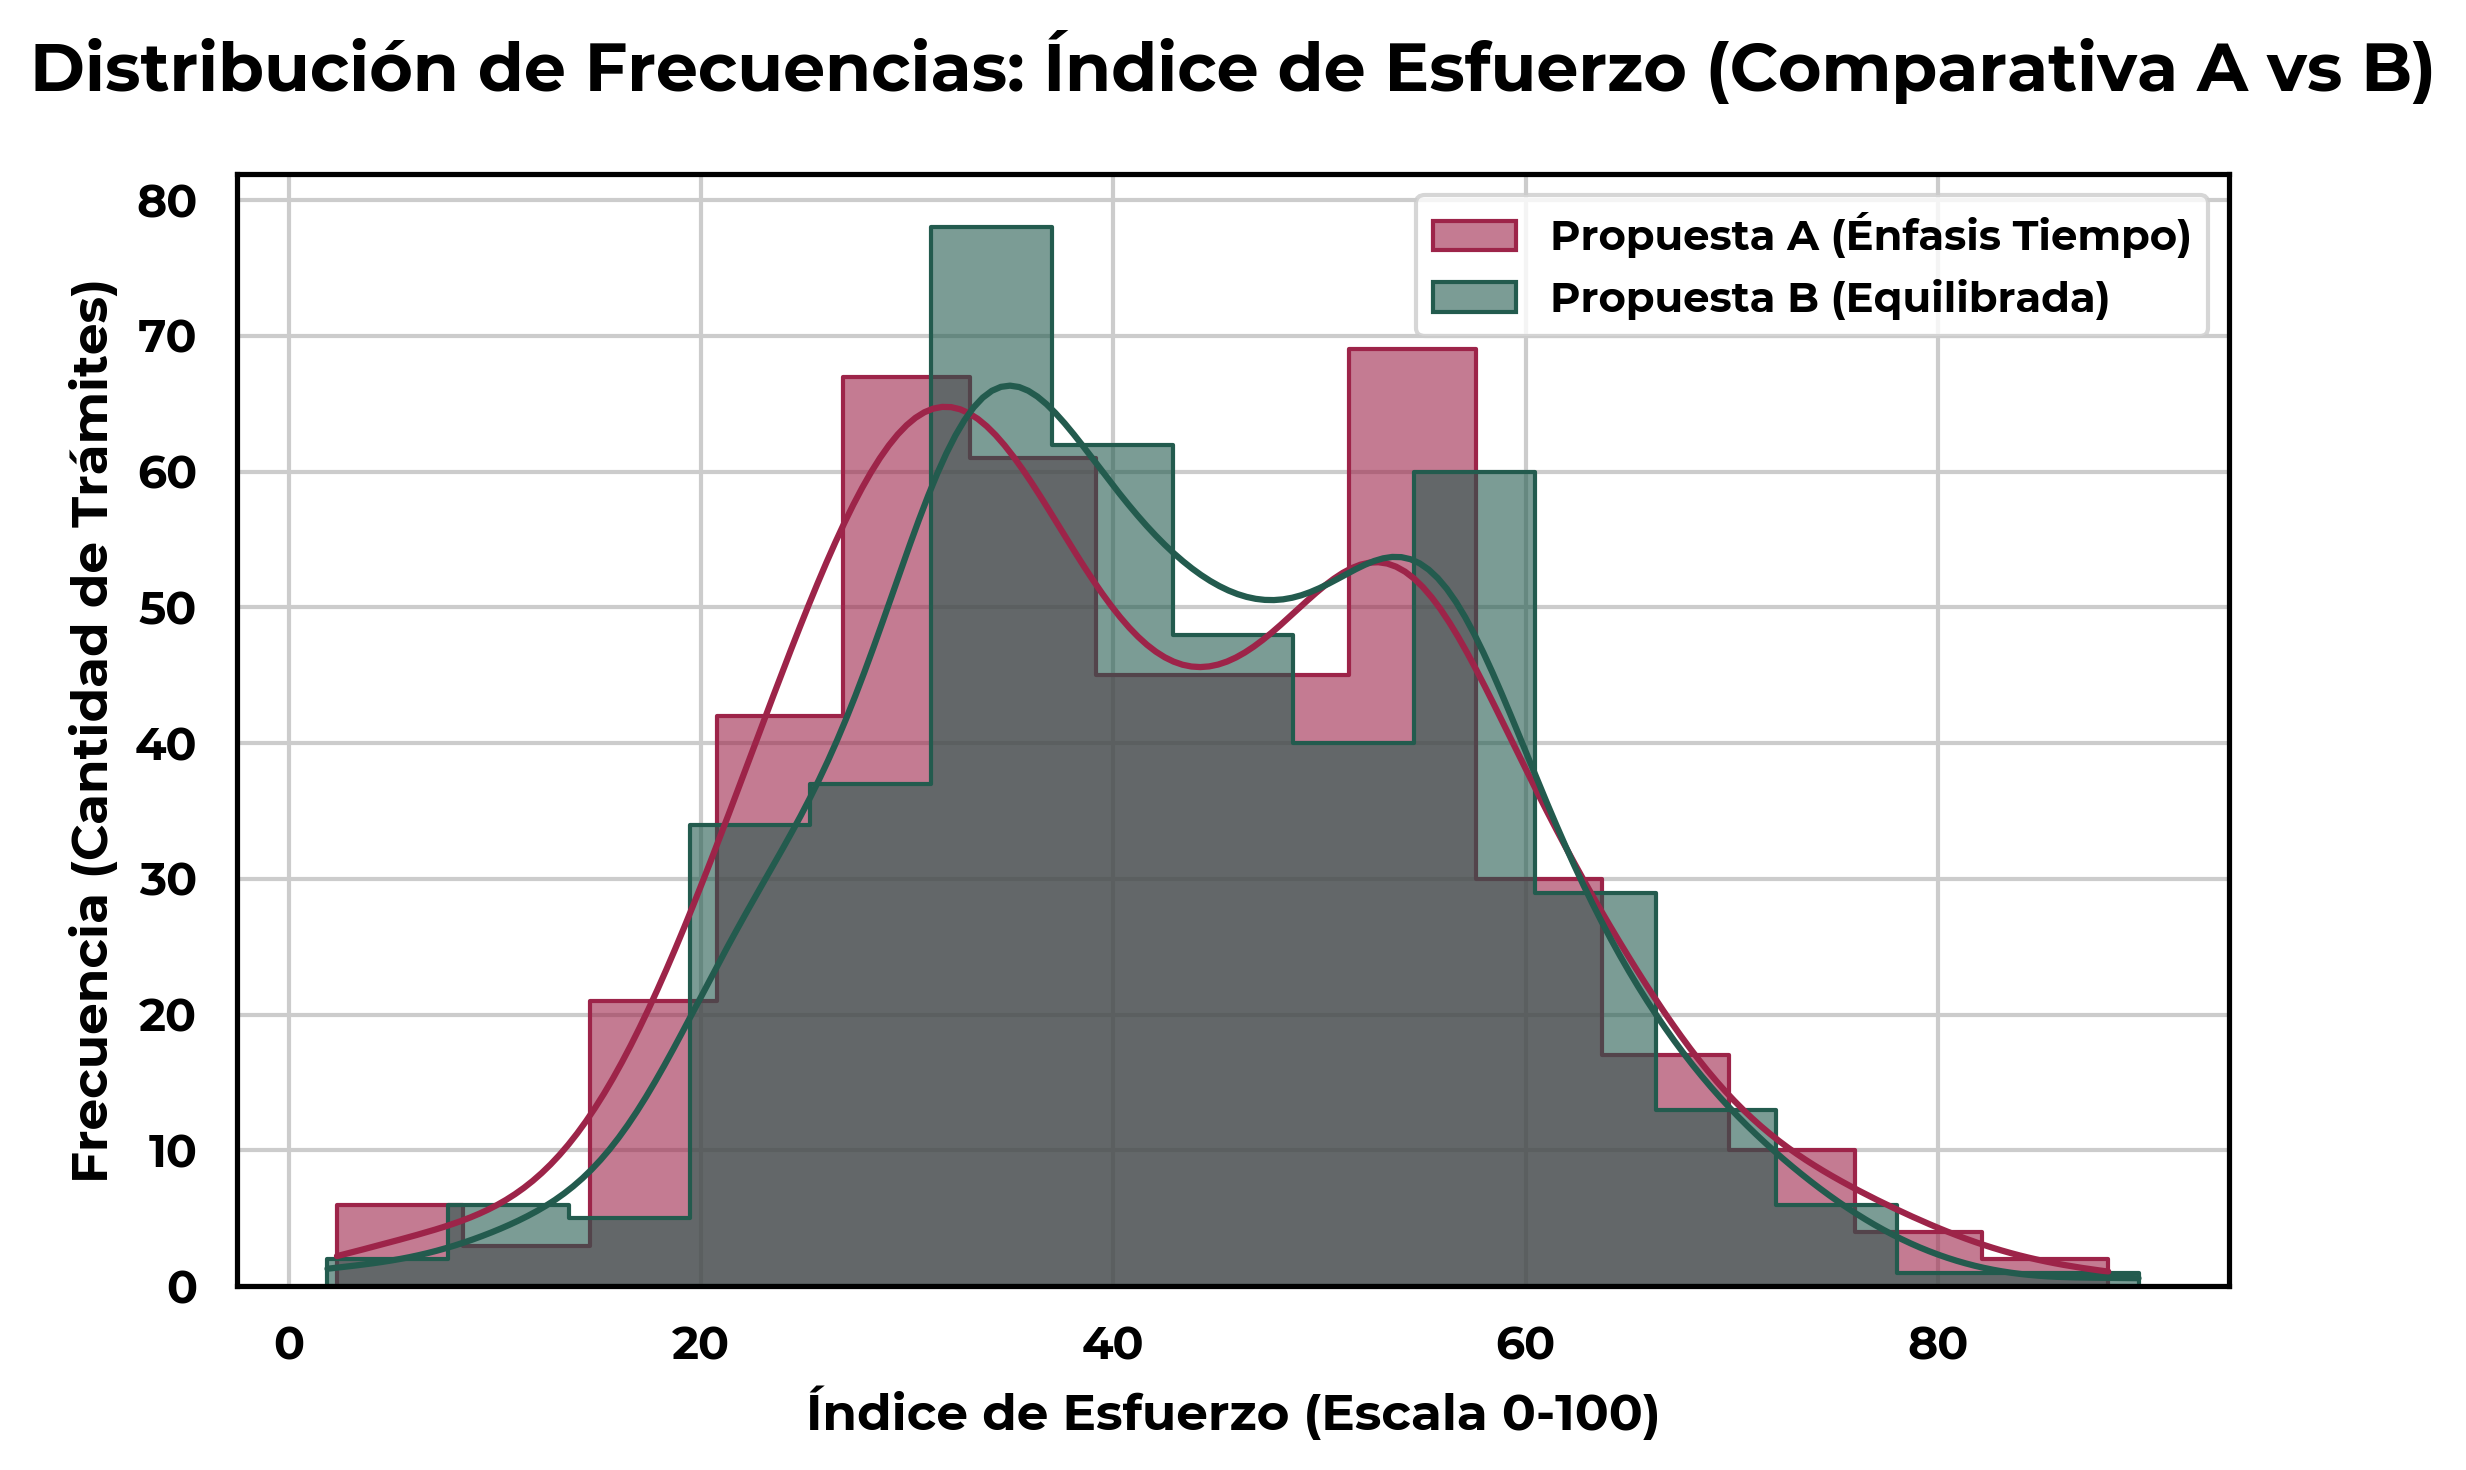

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

guinda_gob = '#9D2449'
verde_gob = '#235B4E'
negro_puro = '#000000'

plt.rcParams['font.family'] = 'Montserrat'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.size'] = 10
plt.rcParams['text.color'] = negro_puro
plt.rcParams['axes.labelcolor'] = negro_puro
plt.rcParams['xtick.color'] = negro_puro
plt.rcParams['ytick.color'] = negro_puro
plt.rcParams['axes.edgecolor'] = negro_puro
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

plt.figure(figsize=(7.5, 5), dpi=300)

sns.histplot(
    data=df, 
    x='IEC_1', 
    color=guinda_gob, 
    label="Propuesta A (Énfasis Tiempo)", 
    kde=True,
    alpha=0.6,
    element="step" 
)

sns.histplot(
    data=df, 
    x='IEC_2', 
    color=verde_gob, 
    label="Propuesta B (Equilibrada)", 
    kde=True, 
    alpha=0.6,
    element="step"
)

plt.title('Distribución de Frecuencias: Índice de Esfuerzo (Comparativa A vs B)', 
          fontsize=16, pad=20)
plt.xlabel('Índice de Esfuerzo (Escala 0-100)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Trámites)', fontsize=12)

legend = plt.legend(fontsize=10, loc='upper right', frameon=True)
plt.setp(legend.get_texts(), color=negro_puro) 

plt.tight_layout()
plt.show()

Se observa que la Propuesta B tiende a correrse un poco más a la derecha de la propuesta A, lo que indica que la primera tiene una forma de más estricta de calificar o ponderar respecto a la segunda, es por ello que de ahora en adelante se trabajará con la propuesta B.

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Top 15 Exlcuyendo Titulaciones
</h4>

Se exluyen los trámites que tengan que ver con titulaciones por su alta frecuencia presentada en los top anteriores, por lo que se presenta un nuevo top 15 exluyendo los trámites de titulación de universidades estatales.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import textwrap


ruta_base_fonts = '/Users/gonza/Downloads/Montserrat-2/static'
ruta_bold = os.path.join(ruta_base_fonts, 'Montserrat-Bold.ttf')
ruta_reg  = os.path.join(ruta_base_fonts, 'Montserrat-Regular.ttf')
ruta_semi = os.path.join(ruta_base_fonts, 'Montserrat-SemiBold.ttf')

for _f in [ruta_bold, ruta_reg, ruta_semi]:
    if os.path.exists(_f): fm.fontManager.addfont(_f)

prop_bold = fm.FontProperties(fname=ruta_bold) if os.path.exists(ruta_bold) else None
prop_reg  = fm.FontProperties(fname=ruta_reg)  if os.path.exists(ruta_reg)  else None
prop_semi = fm.FontProperties(fname=ruta_semi) if os.path.exists(ruta_semi) else None

def ajustar_nombre(texto, ancho=60):
    return "\n".join(textwrap.wrap(str(texto), width=ancho))

sns.set_theme(style="whitegrid")

verde_gob = '#235B4E'
negro_puro = '#000000'

plt.rcParams.update({
    'font.family': 'Montserrat',
    'font.weight': 'bold',
    'text.color': negro_puro,
    'figure.dpi': 300
})

filtro = ~df['Tramite'].astype(str).str.contains("Titulación", case=False, na=False)
df_sin_titulacion = df[filtro].copy()

top_15_clean = df_sin_titulacion.sort_values(by='IEC_2', ascending=False).head(15)
top_15_clean['Tramite_Visual'] = top_15_clean['Tramite'].apply(lambda x: ajustar_nombre(x))

fig, ax = plt.subplots(figsize=(12, 12))

sns.barplot(x='IEC_2', y='Tramite_Visual', data=top_15_clean, color=verde_gob, ax=ax)

ax.set_title('Top 15: Mayor Esfuerzo (Propuesta B) - Excluyendo "Titulación"', 
             pad=20, color=verde_gob, fontproperties=prop_bold, fontsize=16)

ax.set_xlabel('Índice de Esfuerzo (0-100)', color=negro_puro, fontproperties=prop_bold, fontsize=12)
ax.set_ylabel('Trámite', color=negro_puro, fontproperties=prop_bold, fontsize=12)

ax.set_yticklabels(ax.get_yticklabels(), fontproperties=prop_bold, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=prop_reg, fontsize=10)

plt.tight_layout()
plt.show()

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Mapa de Modernización y K-Means.
</h4>

En un análisis un poco más profundo, se plantea comparar en un gráfico el índice digital contra el índice de esfuerzo ciudadano, a fin de poder identificar patrones, como trámites dificiles y poco digitalizados, etc. Del mismo modo se realiza un análisis de K-Means para encontrar agrupamientos naturales a partir de las métricas que definen el "comportamiento" del trámite dentro de los datos, tomando como 4 grupos como base para este análisis.  

PERFILES


,I_Tiempo,I_Requisitos,I_Formatos,I_Digital,I_Costo,Cantidad_Tramites
Cluster,,,,,,
0,39.52,67.31,18.65,82.69,92.31,52
1,37.06,17.37,5.83,94.64,100.00,223
2,31.44,19.78,2.63,19.65,85.96,57
3,39.15,15.25,6.67,94.39,0.00,90


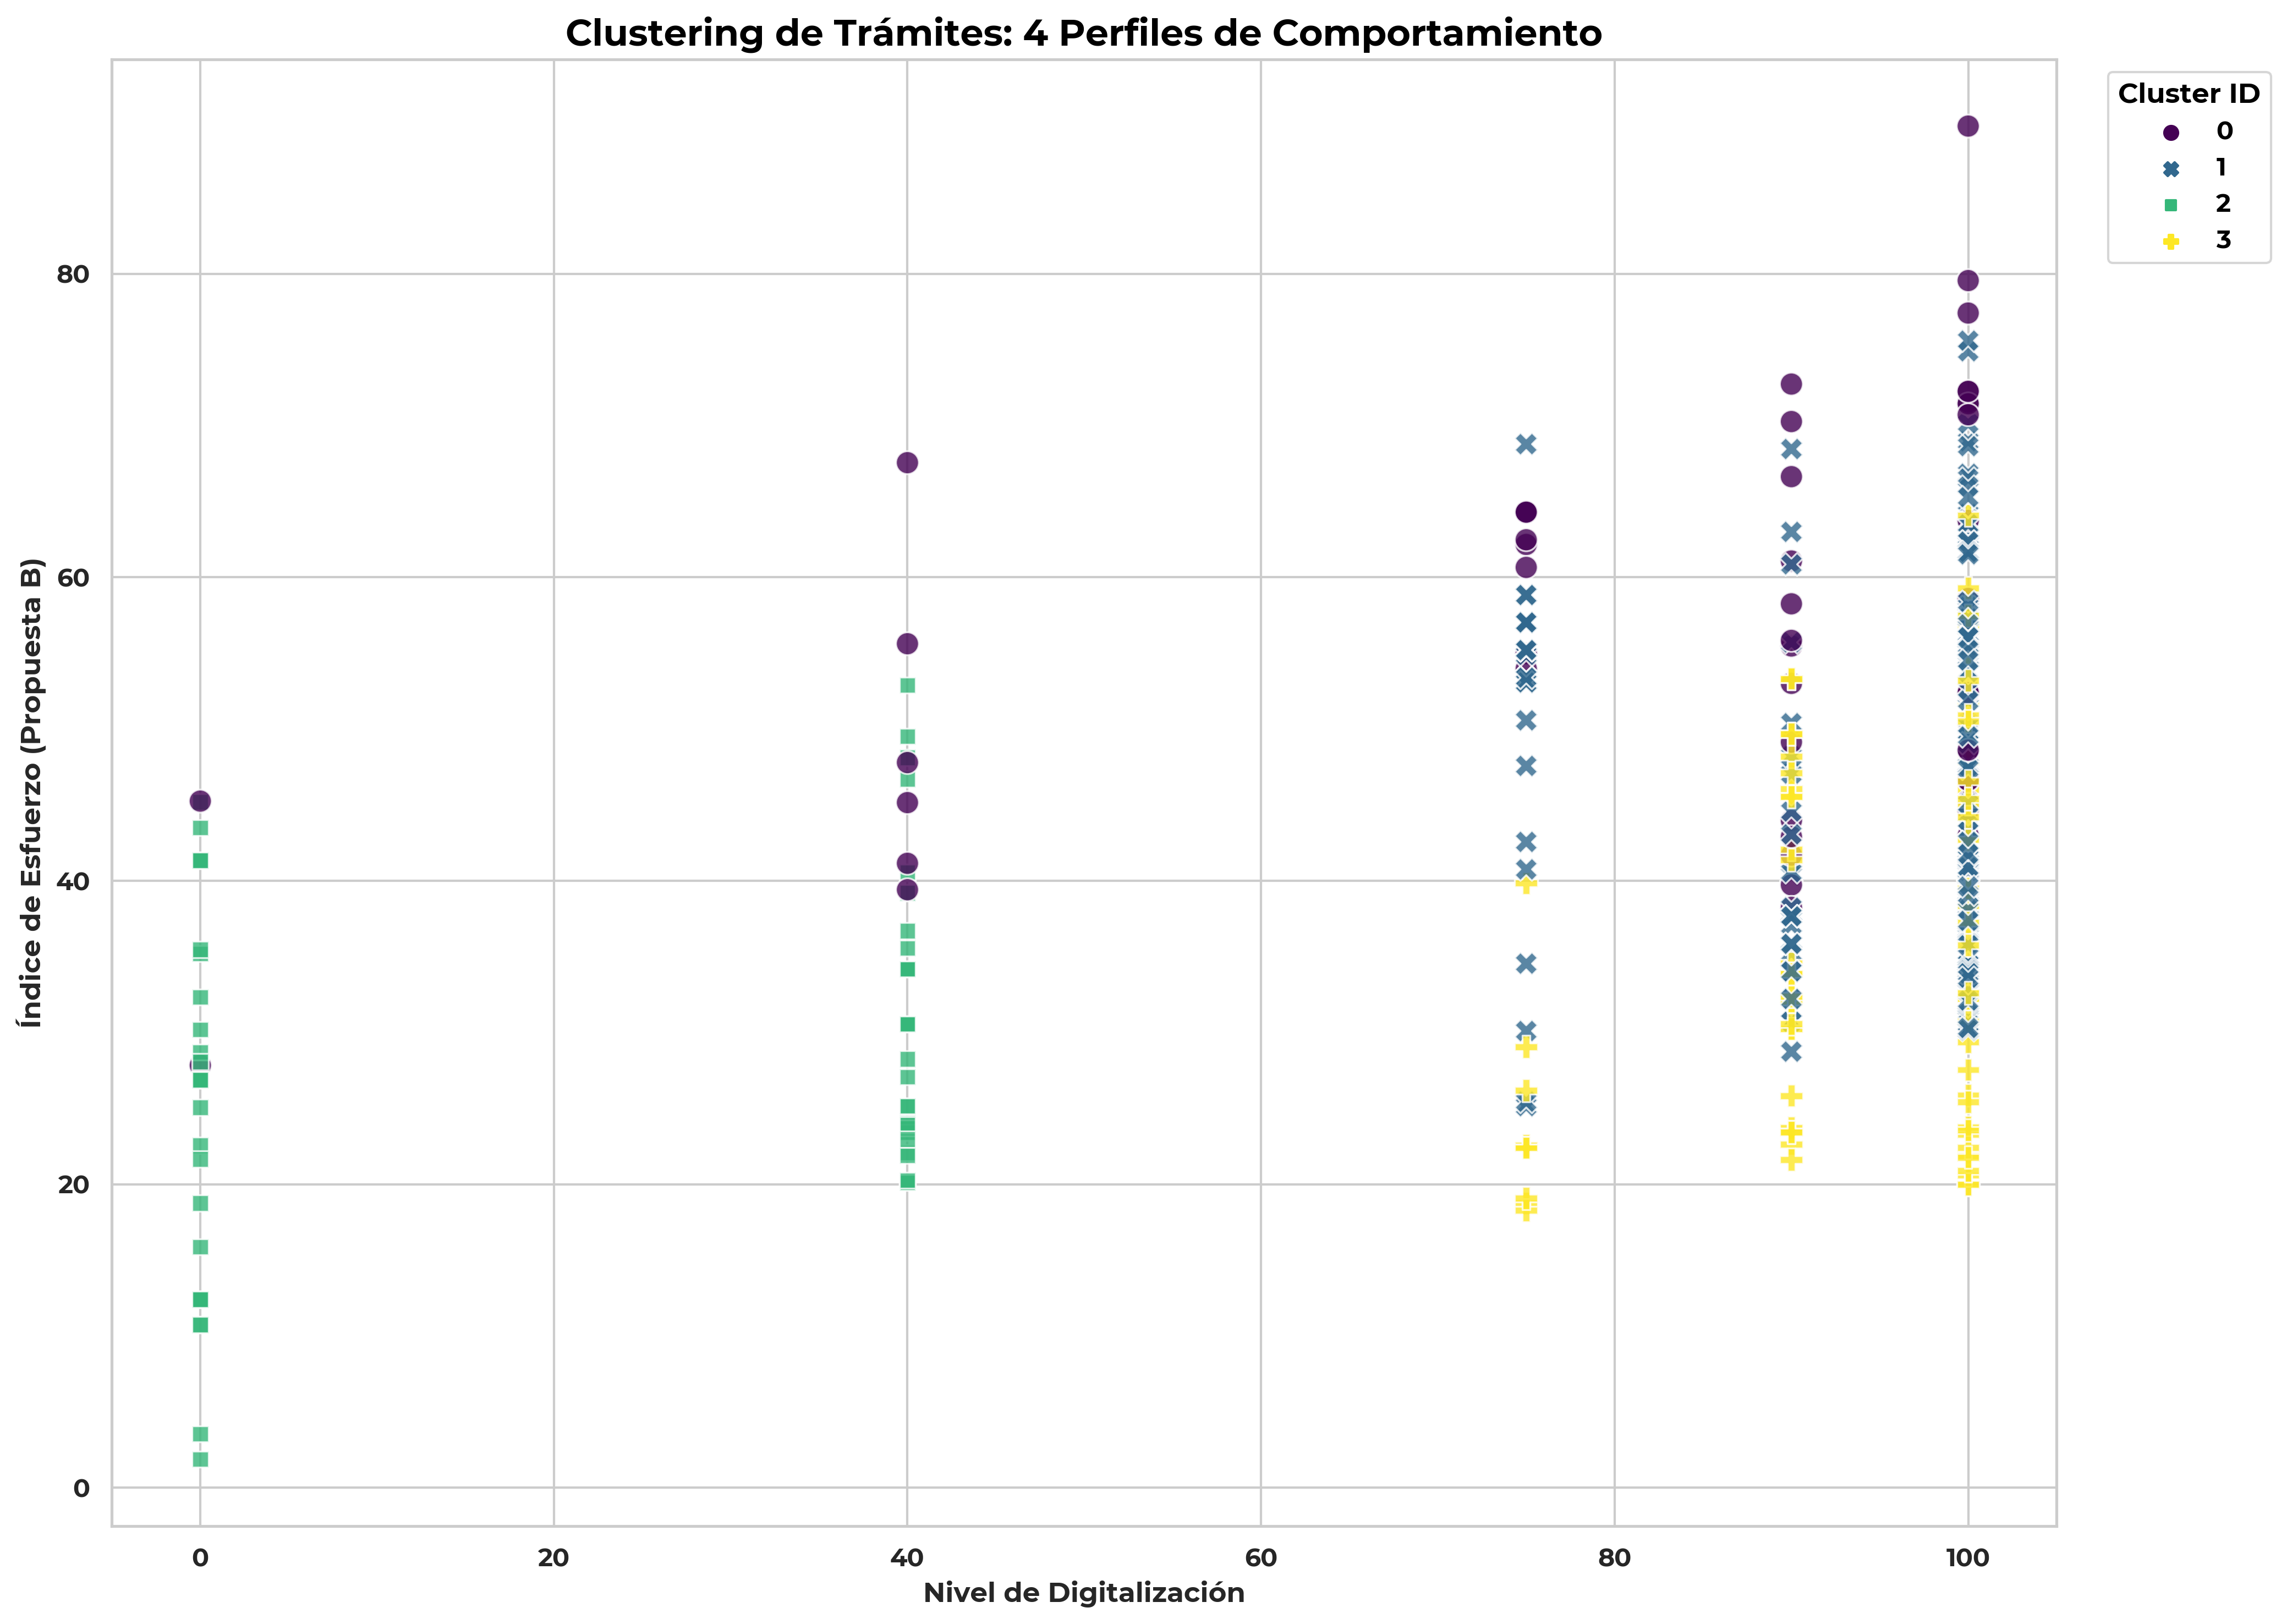

In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Columnas numéricas que definen el "comportamiento" del trámite
features = ['I_Tiempo', 'I_Requisitos', 'I_Formatos', 'I_Digital', 'I_Costo']
df_cluster = df.dropna(subset=features).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[features])

# K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

resumen_clusters = df_cluster.groupby('Cluster')[features].mean().round(2)
resumen_clusters['Cantidad_Tramites'] = df_cluster['Cluster'].value_counts()

print("PERFILES")
display(resumen_clusters)

plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=df_cluster, 
    x='I_Digital', 
    y='IEC_2',       
    hue='Cluster',   
    palette='viridis', 
    s=100, 
    alpha=0.8,
    style='Cluster'
)

plt.title('Clustering de Trámites: 4 Perfiles de Comportamiento', fontsize=16)
plt.xlabel('Nivel de Digitalización')
plt.ylabel('Índice de Esfuerzo (Propuesta B)')
plt.legend(title='Cluster ID', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

df['Cluster'] = df_cluster['Cluster']

Se puede apreciar del mapa de digitalización que los datos se agrupan en ejes verticales, esto se debe a que los niveles de digitalización son discretos, por lo que estos saltos pueden apreciarse de una mejor forma. Por otro lado, son interesantes los resultados del análisis de K-Means. 
1. Cluster 0 (52 trámites): Son trámites o servicios que aunque mantienen un promedio de tiempo similar a los otros 4 grupos y tienen una presencia digital "alta" piden casi tres veces más requisitos y formatos que los demás, es decir, son pesados burocráticamente. 
2. Cluster 1 (223 trámites): Se catalogan como una especie de recaudación eficiente, puesto que todos cobran, presentan una alta presencia de digitalización y son rápidos en primera instancia, sin embargo se propone un análisis posterior a este cluster por el gran número de trámites que cayeron dentro de este.
3. Cluster 2 (57 trámites): Aunque son trámites que se menatienen bajos en trámites, formatos y tiempo, también lo hace en digitalización, por lo que son un área de oportunidad para digitalizar a futuro. 
4. Cluster 3 (90 trámites): Son trámites gratuitos que además mantienen una gran presencia digital, son bajos en requisios, formatos y un tiempo promedio. Pueden emplearse como trámites modelos o la cara amable de la COMERE.


Se exportan 4 documentos con los trámites y servicios agrupados en sus respectivos clusters para su tratamiento por separado.

In [ ]:
os.makedirs('/Users/gonza/Downloads/Effor_index', exist_ok=True)
os.makedirs('/Users/gonza/Downloads/Effor_index/Zoom_de_Acercamiento', exist_ok=True)
ruta_carpeta = '/Users/gonza/Downloads/Effor_index/'

nombres_clusters = {
    0: 'Cluster0_Burocracia_Pesada_Criticos.xlsx',    
    1: 'Cluster1_Recaudacion_Eficiente.xlsx',         
    2: 'Cluster2_Rezago_Analogico_Oportunidad.xlsx',  
    3: 'Cluster3_Servicios_Ciudadanos_Gratuitos.xlsx' 
}

cols_reporte = ['Tramite', 'Secretaria', 'IEC_2', 'I_Tiempo', 'I_Requisitos', 'I_Formatos', 'I_Digital', 'I_Costo']

print("--- Generando Reportes por Perfil ---")

for cluster_id, nombre_archivo in nombres_clusters.items():
    df_grupo = df[df['Cluster'] == cluster_id].copy()
    
    df_grupo = df_grupo.sort_values(by='IEC_2', ascending=False)
    
    ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)
    
    df_grupo[cols_reporte].to_excel(ruta_completa, index=False)
    
    print(f"Generado: {nombre_archivo} | ({len(df_grupo)} trámites)")

print(f"\nTodos los archivos se guardaron en: {ruta_carpeta}")

<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Análisis
</h4>

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Conteo neto de trámites analizados
</h4>

In [16]:
df_con_indice = df[df['IEC_2'].notna()].copy()

total_neto = len(df_con_indice)

desglose_secretaria = df_con_indice['Secretaria'].value_counts().reset_index()
desglose_secretaria.columns = ['Secretaría', 'Cantidad de Trámites']

print(f"RESUMEN EJECUTIVO:")
print(f"Total de trámites a los que se les pudo calcular el IEC_2: {total_neto}")
print("-" * 80)
print("Desglose por Dependencia:")

try:
    display(desglose_secretaria)
except:
    print(desglose_secretaria)

RESUMEN EJECUTIVO:
Total de trámites a los que se les pudo calcular el IEC_2: 422
--------------------------------------------------------------------------------
Desglose por Dependencia:


,Secretaría,Cantidad de Trámites
0,Secretaría de Educación Pública,210
1,Secretaría de Gobierno,61
2,Secretaría de Infraestructura Pública y Desarr...,28
3,Secretaría de Salud,23
4,Secretaría de Agricultura y Desarrollo Rural,19
5,Secretaría de Movilidad y Transporte,16
6,Secretaría de Hacienda,12
7,Secretaría de Trabajo y Previsión Social,12
8,Secretaría de Desarrollo Económico,10
9,Procuraduría General de Justicia,7


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns


ruta_base_fonts = '/Users/gonza/Downloads/Montserrat-2/static'
ruta_bold = os.path.join(ruta_base_fonts, 'Montserrat-Bold.ttf')
ruta_reg  = os.path.join(ruta_base_fonts, 'Montserrat-Regular.ttf')
ruta_semi = os.path.join(ruta_base_fonts, 'Montserrat-SemiBold.ttf')

for _f in [ruta_bold, ruta_reg, ruta_semi]:
    if os.path.exists(_f): fm.fontManager.addfont(_f)

prop_bold = fm.FontProperties(fname=ruta_bold) if os.path.exists(ruta_bold) else None
prop_reg  = fm.FontProperties(fname=ruta_reg)  if os.path.exists(ruta_reg)  else None
prop_semi = fm.FontProperties(fname=ruta_semi) if os.path.exists(ruta_semi) else None

sns.set_theme(style="white")

guinda_gob = '#9D2449'
negro_puro = '#000000'

plt.rcParams.update({
    'font.family': 'Montserrat',
    'font.weight': 'bold',
    'text.color': negro_puro,
    'figure.dpi': 300
})

colores_guinda_vino = [
    '#9D2449', '#781C38', '#B03052', '#5E162B',  
    '#8C2040', '#45101F', '#A6264A', '#6B1831', '#D1486B'  
]

df_con_indice = df[df['IEC_2'].notna()].copy()
total_neto = len(df_con_indice)
desglose = df_con_indice['Secretaria'].value_counts()

datos = desglose.values
etiquetas = desglose.index
porcentajes = 100. * datos / datos.sum()

if len(datos) > len(colores_guinda_vino):
    colores_usar = (colores_guinda_vino * 2)[:len(datos)]
else:
    colores_usar = colores_guinda_vino[:len(datos)]

fig, ax = plt.subplots(figsize=(14, 8))

wedges, texts = ax.pie(
    datos, 
    startangle=90, 
    colors=colores_usar,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=1.5)
)

centro_circulo = plt.Circle((0,0), 0.60, fc='white')
ax.add_artist(centro_circulo)

ax.text(0, 0.1, f"{total_neto}", ha='center', va='center', 
         color=guinda_gob, fontproperties=prop_bold, fontsize=32)
ax.text(0, -0.1, "Trámites\nAnalizados", ha='center', va='center', 
         color='#333333', fontproperties=prop_reg, fontsize=11)

etiquetas_leyenda = [f'{p:.1f}%  -  {l}' for l, p in zip(etiquetas, porcentajes)]

leg = ax.legend(
    wedges, 
    etiquetas_leyenda, 
    title="Distribución por Dependencia",
    loc="center left",
    bbox_to_anchor=(0.95, 0, 0.5, 1),
    frameon=False,
    prop=prop_reg
)
plt.setp(leg.get_title(), fontproperties=prop_bold, fontsize=12)

ax.set_title('Cobertura del Índice de Esfuerzo Ciudadano', 
             color=guinda_gob, pad=20, fontproperties=prop_bold, fontsize=20)

plt.tight_layout()
plt.show()

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Cluster 0: Burocraia Pesada
</h4>

In [ ]:
ruta = "/Users/gonza/Downloads/Effor_index/Cluster0_Burocracia_Pesada_Criticos.xlsx"
df2 = pd.read_excel(ruta)

# Conteo por Secretaría
total_tramites = len(df2)
conteo = df2["Secretaria"].value_counts()

porcentajes = df2["Secretaria"].value_counts(normalize=True) * 100

resumen = pd.DataFrame({
    'Trámites': conteo,
    'Participación (%)': porcentajes
})

resumen['Participación (%)'] = resumen['Participación (%)'].map('{:.2f}%'.format)

print(f"\nANÁLISIS DE CONCENTRACIÓN - CLUSTER 0")
print(f"Total de trámites en este grupo: {total_tramites}")
print("-" * 60)
print("Desglose por Secretaría:")
display(resumen)

top_sec = resumen.index[0]
top_pct = resumen.iloc[0]['Participación (%)']

In [ ]:
df_total = df.copy()

ruta_cluster = "/Users/gonza/Downloads/Effor_index/Cluster0_Burocracia_Pesada_Criticos.xlsx"
df_cluster = pd.read_excel(ruta_cluster)

peso_global = df_total["Secretaria"].value_counts(normalize=True) * 100

peso_cluster = df_cluster["Secretaria"].value_counts(normalize=True) * 100

conteo_cluster = df_cluster["Secretaria"].value_counts()

comparativa = pd.DataFrame({
    'Num_Tramites_Cluster': conteo_cluster,
    '%_En_Cluster': peso_cluster,
    '%_En_Total_Gobierno': peso_global
})

comparativa = comparativa.fillna(0)

comparativa = comparativa[comparativa['Num_Tramites_Cluster'] > 0]

# CÁLCULO DEL "ÍNDICE DE CONCENTRACIÓN"
# Se divide Dividimos su presencia en el cluster entre su presencia global.
# > 1 : Está SOBRERREPRESENTADA (Aporta más problemas de lo que le toca por tamaño)
# < 1 : Está SUBREPRESENTADA (Aporta menos problemas de lo esperado)
# = 1 : Es proporcional a su tamaño
comparativa['Indice_Concentracion'] = comparativa['%_En_Cluster'] / comparativa['%_En_Total_Gobierno']

comparativa = comparativa.sort_values(by='Indice_Concentracion', ascending=False)

tabla_final = comparativa.style.format({
    'Num_Tramites_Cluster': '{:.0f}',
    '%_En_Cluster': '{:.2f}%',
    '%_En_Total_Gobierno': '{:.2f}%',
    'Indice_Concentracion': '{:.2f}'
}).background_gradient(subset=['Indice_Concentracion'], cmap='Reds')

print(f"Total de trámites en Cluster 0: {len(df_cluster)}")
print("Tabla Comparativa: Peso en el Cluster vs. Peso Real en Gobierno")
display(tabla_final)

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Cluster 1: Recaudación Eficiente
</h4>

In [ ]:
df_total = df.copy()

ruta_cluster = "/Users/gonza/Downloads/Effor_index/Cluster1_Recaudacion_Eficiente.xlsx"
df_cluster = pd.read_excel(ruta_cluster)

peso_global = df_total["Secretaria"].value_counts(normalize=True) * 100

peso_cluster = df_cluster["Secretaria"].value_counts(normalize=True) * 100

conteo_cluster = df_cluster["Secretaria"].value_counts()

comparativa = pd.DataFrame({
    'Num_Tramites_Cluster': conteo_cluster,
    '%_En_Cluster': peso_cluster,
    '%_En_Total_Gobierno': peso_global
})

comparativa = comparativa.fillna(0)

comparativa = comparativa[comparativa['Num_Tramites_Cluster'] > 0]

comparativa['Indice_Concentracion'] = comparativa['%_En_Cluster'] / comparativa['%_En_Total_Gobierno']

comparativa = comparativa.sort_values(by='Indice_Concentracion', ascending=False)

tabla_final = comparativa.style.format({
    'Num_Tramites_Cluster': '{:.0f}',
    '%_En_Cluster': '{:.2f}%',
    '%_En_Total_Gobierno': '{:.2f}%',
    'Indice_Concentracion': '{:.2f}'
}).background_gradient(subset=['Indice_Concentracion'], cmap='Reds')

print(f"Total de trámites en Cluster 1: {len(df_cluster)}")
print("Tabla Comparativa: Peso en el Cluster vs. Peso Real en Gobierno")
display(tabla_final)

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Cluster 2: Rezago Analógico.
</h4>

In [ ]:
df_total = df.copy()

ruta_cluster = "/Users/gonza/Downloads/Effor_index/Cluster2_Rezago_Analogico_Oportunidad.xlsx"
df_cluster = pd.read_excel(ruta_cluster)

peso_global = df_total["Secretaria"].value_counts(normalize=True) * 100

peso_cluster = df_cluster["Secretaria"].value_counts(normalize=True) * 100

conteo_cluster = df_cluster["Secretaria"].value_counts()

comparativa = pd.DataFrame({
    'Num_Tramites_Cluster': conteo_cluster,
    '%_En_Cluster': peso_cluster,
    '%_En_Total_Gobierno': peso_global
})

comparativa = comparativa.fillna(0)

comparativa = comparativa[comparativa['Num_Tramites_Cluster'] > 0]

comparativa['Indice_Concentracion'] = comparativa['%_En_Cluster'] / comparativa['%_En_Total_Gobierno']

comparativa = comparativa.sort_values(by='Indice_Concentracion', ascending=False)

tabla_final = comparativa.style.format({
    'Num_Tramites_Cluster': '{:.0f}',
    '%_En_Cluster': '{:.2f}%',
    '%_En_Total_Gobierno': '{:.2f}%',
    'Indice_Concentracion': '{:.2f}'
}).background_gradient(subset=['Indice_Concentracion'], cmap='Reds')

print(f"Total de trámites en Cluster 2: {len(df_cluster)}")
print("Tabla Comparativa: Peso en el Cluster vs. Peso Real en Gobierno")
display(tabla_final)

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Cluster 3: Servicios Gratuitos.
</h4>

In [ ]:
df_total = df.copy()

ruta_cluster = "/Users/gonza/Downloads/Effor_index/Cluster3_Servicios_Ciudadanos_Gratuitos.xlsx"
df_cluster = pd.read_excel(ruta_cluster)

peso_global = df_total["Secretaria"].value_counts(normalize=True) * 100

peso_cluster = df_cluster["Secretaria"].value_counts(normalize=True) * 100

conteo_cluster = df_cluster["Secretaria"].value_counts()

comparativa = pd.DataFrame({
    'Num_Tramites_Cluster': conteo_cluster,
    '%_En_Cluster': peso_cluster,
    '%_En_Total_Gobierno': peso_global
})

comparativa = comparativa.fillna(0)

comparativa = comparativa[comparativa['Num_Tramites_Cluster'] > 0]

comparativa['Indice_Concentracion'] = comparativa['%_En_Cluster'] / comparativa['%_En_Total_Gobierno']

comparativa = comparativa.sort_values(by='Indice_Concentracion', ascending=False)

tabla_final = comparativa.style.format({
    'Num_Tramites_Cluster': '{:.0f}',
    '%_En_Cluster': '{:.2f}%',
    '%_En_Total_Gobierno': '{:.2f}%',
    'Indice_Concentracion': '{:.2f}'
}).background_gradient(subset=['Indice_Concentracion'], cmap='Reds')

print(f"Total de trámites en Cluster 3: {len(df_cluster)}")
print("Tabla Comparativa: Peso en el Cluster vs. Peso Real en Gobierno")
display(tabla_final)

<h4 style="color:#0F3D36; font-family:'Montserrat', sans-serif; font-size:20px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Zoom de seguimiento.
</h4>

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Excluyendo la Secretaría de Educación Pública
</h4>

Como se observó en el análisis anterior, la Secretaría de Eduación Pública abarca casi el $50\%$ del universo de trámites y servicios, si bien se encontraron resultados interesantes como que es una de las Secretarías con una gran área de oprtunidad para digitalizar sus trámites, la diferencia en proporciones con las demás secretarías oculta algunos otros trámites y servicios que pudieram presentar algún problema. Por ello, se realiza el mismo análisis presentado anteriormente pero excluyendo a la Secretaría de Educación Pública.

In [23]:
total_original = len(df)

filtro_no_sep = ~df['Secretaria'].astype(str).str.contains("Educación Pública", case=False, na=False)

df_no_sep = df[filtro_no_sep].copy()

eliminados = total_original - len(df_no_sep)
print(f"Análisis de Filtrado:")
print(f"Total original: {total_original} trámites.")
print(f"Trámites de la SEP eliminados: {eliminados}")
print(f"Nuevo universo de trabajo (df_no_sep): {len(df_no_sep)} trámites.")

Análisis de Filtrado:
Total original: 666 trámites.
Trámites de la SEP eliminados: 254
Nuevo universo de trabajo (df_no_sep): 412 trámites.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns


ruta_base_fonts = '/Users/gonza/Downloads/Montserrat-2/static'
ruta_bold = os.path.join(ruta_base_fonts, 'Montserrat-Bold.ttf')
ruta_reg  = os.path.join(ruta_base_fonts, 'Montserrat-Regular.ttf')
ruta_semi = os.path.join(ruta_base_fonts, 'Montserrat-SemiBold.ttf')

for _f in [ruta_bold, ruta_reg, ruta_semi]:
    if os.path.exists(_f): fm.fontManager.addfont(_f)

prop_bold = fm.FontProperties(fname=ruta_bold) if os.path.exists(ruta_bold) else None
prop_reg  = fm.FontProperties(fname=ruta_reg)  if os.path.exists(ruta_reg)  else None
prop_semi = fm.FontProperties(fname=ruta_semi) if os.path.exists(ruta_semi) else None

ruta_carpeta = '/Users/gonza/Downloads/Effor_index/Zoom_de_Acercamiento/'
if not os.path.exists(ruta_carpeta):
    os.makedirs(ruta_carpeta)

sns.set_theme(style="whitegrid")

guinda_gob = '#9D2449'
verde_gob = '#235B4E'
negro_puro = '#000000'

plt.rcParams.update({
    'font.family': 'Montserrat',
    'font.weight': 'bold',
    'text.color': negro_puro,
    'figure.dpi': 300
})

plt.figure(figsize=(14, 8))

sns.histplot(
    data=df_no_sep, 
    x='IEC_1', 
    color=guinda_gob, 
    label="Propuesta A (Énfasis Tiempo)", 
    kde=True, 
    alpha=0.4,           
    element="bars",      
    line_kws={'linewidth': 3} 
)

sns.histplot(
    data=df_no_sep, 
    x='IEC_2', 
    color=verde_gob, 
    label="Propuesta B (Equilibrada)", 
    kde=True, 
    alpha=0.4,
    element="bars",
    line_kws={'linewidth': 3}
)

plt.title('Distribución de Esfuerzo Ciudadano (Sin SEP)\nAnálisis de Comportamiento Bimodal', 
          fontsize=18, pad=25, color=negro_puro, fontproperties=prop_bold)

plt.xlabel('Índice de Esfuerzo (0 - 100)', fontsize=14, labelpad=15, fontproperties=prop_bold)
plt.ylabel('Cantidad de Trámites', fontsize=14, labelpad=15, fontproperties=prop_bold)

plt.xticks(fontproperties=prop_reg, fontsize=11)
plt.yticks(fontproperties=prop_reg, fontsize=11)

leg = plt.legend(title="Metodología de Cálculo", frameon=True, shadow=True, prop=prop_reg)
plt.setp(leg.get_title(), fontproperties=prop_bold, fontsize=12)

plt.xlim(0, 100)
plt.tight_layout()
plt.show()

Se observa que la propuesta B es un poco más estricta para calificar respecto a la A, es importante notar que para este caso se tiene ahora un comportamiento bimodal más marcado, lo que puede indicar dos poblaciones diferentes entorno a $0-40$ puntos y $60-85$ puntos.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns


ruta_base_fonts = '/Users/gonza/Downloads/Montserrat-2/static'
ruta_bold = os.path.join(ruta_base_fonts, 'Montserrat-Bold.ttf')
ruta_reg  = os.path.join(ruta_base_fonts, 'Montserrat-Regular.ttf')
ruta_semi = os.path.join(ruta_base_fonts, 'Montserrat-SemiBold.ttf')

for _f in [ruta_bold, ruta_reg, ruta_semi]:
    if os.path.exists(_f): fm.fontManager.addfont(_f)

prop_bold = fm.FontProperties(fname=ruta_bold) if os.path.exists(ruta_bold) else None
prop_reg  = fm.FontProperties(fname=ruta_reg)  if os.path.exists(ruta_reg)  else None
prop_semi = fm.FontProperties(fname=ruta_semi) if os.path.exists(ruta_semi) else None

sns.set_theme(style="white")

guinda_gob = '#9D2449'
negro_puro = '#000000'

plt.rcParams.update({
    'font.family': 'Montserrat',
    'font.weight': 'bold',
    'text.color': negro_puro,
    'figure.dpi': 300
})

colores_guinda_vino = [
    '#9D2449', '#781C38', '#B03052', '#5E162B',  
    '#8C2040', '#45101F', '#A6264A', '#6B1831', '#D1486B'  
]

df_con_indice = df_no_sep[df_no_sep['IEC_2'].notna()].copy()
total_neto = len(df_con_indice)
desglose = df_con_indice['Secretaria'].value_counts()

datos = desglose.values
etiquetas = desglose.index
porcentajes = 100. * datos / datos.sum()

if len(datos) > len(colores_guinda_vino):
    colores_usar = (colores_guinda_vino * ((len(datos) // len(colores_guinda_vino)) + 1))[:len(datos)]
else:
    colores_usar = colores_guinda_vino[:len(datos)]

fig, ax = plt.subplots(figsize=(14, 8))

wedges, texts = ax.pie(
    datos, 
    startangle=90, 
    colors=colores_usar,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=1.5)
)

centro_circulo = plt.Circle((0,0), 0.60, fc='white')
ax.add_artist(centro_circulo)

ax.text(0, 0.1, f"{total_neto}", ha='center', va='center', 
         color=guinda_gob, fontproperties=prop_bold, fontsize=32)
ax.text(0, -0.1, "Trámites\nAnalizados", ha='center', va='center', 
         color='#333333', fontproperties=prop_reg, fontsize=11)

etiquetas_leyenda = [f'{p:.1f}%  -  {l}' for l, p in zip(etiquetas, porcentajes)]

leg = ax.legend(
    wedges, 
    etiquetas_leyenda, 
    title="Distribución por Dependencia",
    loc="center left",
    bbox_to_anchor=(0.95, 0, 0.5, 1),
    frameon=False,
    prop=prop_reg
)
plt.setp(leg.get_title(), fontproperties=prop_bold, fontsize=12)

ax.set_title('Cobertura del Índice de Esfuerzo (Excluyendo SEP)', 
             color=guinda_gob, pad=20, fontproperties=prop_bold, fontsize=20)

plt.tight_layout()
plt.show()

El conjunto de trámites analizados se redujo considerablemente a solo 212, ya que la SEP ocupaba un $50\%$ de los mismo, como ya se mencionó anteriormente. 

In [ ]:
ruta_carpeta = '/Users/gonza/Downloads/Effor_index/Zoom_de_Acercamiento/'

if not os.path.exists(ruta_carpeta):
    os.makedirs(ruta_carpeta)

df_no_sep_ordenado = df_no_sep.sort_values(by='IEC_2', ascending=False)

nombre_archivo = "Effor_index_No_SEP.xlsx"
ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)

df_no_sep_ordenado.to_excel(ruta_completa, index=False)

print(f"Archivo guardado con éxito en:\n{ruta_completa}")
print(f"Total de trámites procesados: {len(df_no_sep_ordenado)}")

In [ ]:
ruta_zoom = '/Users/gonza/Downloads/Effor_index/Zoom_de_Acercamiento'
os.makedirs(ruta_zoom, exist_ok=True)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import textwrap


ruta_base_fonts = '/Users/gonza/Downloads/Montserrat-2/static'
ruta_bold = os.path.join(ruta_base_fonts, 'Montserrat-Bold.ttf')
ruta_reg  = os.path.join(ruta_base_fonts, 'Montserrat-Regular.ttf')
ruta_semi = os.path.join(ruta_base_fonts, 'Montserrat-SemiBold.ttf')

for _f in [ruta_bold, ruta_reg, ruta_semi]:
    if os.path.exists(_f): fm.fontManager.addfont(_f)

prop_bold = fm.FontProperties(fname=ruta_bold) if os.path.exists(ruta_bold) else None
prop_reg  = fm.FontProperties(fname=ruta_reg)  if os.path.exists(ruta_reg)  else None
prop_semi = fm.FontProperties(fname=ruta_semi) if os.path.exists(ruta_semi) else None

if not os.path.exists(ruta_zoom):
    os.makedirs(ruta_zoom)

def ajustar_nombre(texto, ancho=45):
    return "\n".join(textwrap.wrap(str(texto), width=ancho))

sns.set_theme(style="whitegrid")
guinda_gob = '#9D2449'
negro_puro = '#000000'

plt.rcParams.update({
    'font.family': 'Montserrat',
    'font.weight': 'bold',
    'text.color': negro_puro,
    'figure.dpi': 300
})

df_plot_B = df_no_sep.sort_values(by='IEC_2', ascending=False).head(20).copy()
df_plot_B['Tramite_Visual'] = df_plot_B['Tramite'].apply(lambda x: ajustar_nombre(x))

fig, ax_b = plt.subplots(figsize=(12, 10))
sns.barplot(x='IEC_2', y='Tramite_Visual', data=df_plot_B, color=guinda_gob, ax=ax_b)

ax_b.bar_label(ax_b.containers[0], fmt='%.1f', padding=5, fontproperties=prop_bold, fontsize=10)

ax_b.set_title('Top 15 Trámites: Mayor Esfuerzo (Sin SEP) - Propuesta B', 
             pad=20, color=guinda_gob, fontproperties=prop_bold, fontsize=18)

ax_b.set_xlabel('Índice de Esfuerzo (Equilibrado)', color=negro_puro, fontproperties=prop_bold, fontsize=14)
ax_b.set_ylabel('Trámite', color=negro_puro, fontproperties=prop_bold, fontsize=14)

ax_b.set_yticklabels(ax_b.get_yticklabels(), fontproperties=prop_bold, fontsize=10)
ax_b.set_xticklabels(ax_b.get_xticklabels(), fontproperties=prop_reg, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(ruta_zoom, 'Top20_SinSEP_Propuesta_B.png'))
plt.show()

cols_export = ['Secretaria', 'Tramite', 'IEC_1', 'IEC_2', 'I_Tiempo', 'I_Requisitos', 'I_Formatos', 'I_Digital', 'I_Costo']
top_15_zoom = df_no_sep.sort_values(by='IEC_2', ascending=False).head(15)[cols_export]
top_15_zoom.to_excel(os.path.join(ruta_zoom, 'Top15_SinSEP_Criticos.xlsx'), index=False)

print(f"Proceso completado. Archivos en: {ruta_zoom}")

Se realiza un análisis de K-Means nuevamente, aunque en esta ocasión solo con 3 clusters. 

In [ ]:
ruta_zoom = '/Users/gonza/Downloads/Effor_index/Zoom_de_Acercamiento'
os.makedirs(ruta_zoom, exist_ok=True)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = ['I_Tiempo', 'I_Requisitos', 'I_Formatos', 'I_Digital', 'I_Costo']

df_cluster = df_no_sep.dropna(subset=features).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

resumen_clusters = df_cluster.groupby('Cluster')[features].mean().round(2)
resumen_clusters['Cantidad_Tramites'] = df_cluster['Cluster'].value_counts()
resumen_clusters['%_Representacion'] = (resumen_clusters['Cantidad_Tramites'] / len(df_cluster) * 100).round(1)

print("--- PERFILES DE COMPORTAMIENTO (SIN SEP) ---")
display(resumen_clusters)

df_no_sep['Cluster'] = df_cluster['Cluster']

archivo_final = os.path.join(ruta_zoom, 'Clustering_Sin_SEP_Resultados.xlsx')
df_no_sep.to_excel(archivo_final, index=False)
print(f"\nAnálisis de clusters guardado en: {archivo_final}")

In [ ]:
os.makedirs('/Users/gonza/Downloads/Effor_index', exist_ok=True)
os.makedirs('/Users/gonza/Downloads/Effor_index/Zoom_de_Acercamiento', exist_ok=True)
ruta_carpeta = "/Users/gonza/Downloads/Effor_index/Zoom_de_Acercamiento"

nombres_clusters = {
    0: 'Cluster0_Área_de_Oportunidad.xlsx',    
    1: 'Cluster1_Gratuitos_Eficientes.xlsx',         
    2: 'Cluster2_Carga_Burocrática.xlsx',   
}

# --- AGREGAMOS 'TraPersona' A LAS COLUMNAS ---
cols_reporte = [
    'Tramite', 'Secretaria', 'TraPersona', 'IEC_2', 
    'I_Tiempo', 'I_Requisitos', 'I_Formatos', 'I_Digital', 'I_Costo'
]

print("--- Generando Reportes por Perfil (Incluyendo Tipo de Persona) ---")

for cluster_id, nombre_archivo in nombres_clusters.items():
    # Filtramos desde df_no_sep (asegúrate de haber corrido el bloque de recuperación si reiniciaste)
    df_grupo = df_no_sep[df_no_sep['Cluster'] == cluster_id].copy()
    
    df_grupo = df_grupo.sort_values(by='IEC_2', ascending=False)
    
    ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)
    
    # Exportamos con la nueva columna
    df_grupo[cols_reporte].to_excel(ruta_completa, index=False)
    
    print(f"✅ Actualizado: {nombre_archivo} | ({len(df_grupo)} trámites)")

print(f"\nTodos los archivos con la columna 'TraPersona' se guardaron en: {ruta_carpeta}")

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Cluster 0: Áreas de Oportunidad
</h4>

In [30]:
target_cluster = 0
nombre_del_grupo = "Área de Oportunidad"

df_total_analizado = df_no_sep.copy()
df_cluster_critico = df_no_sep[df_no_sep['Cluster'] == target_cluster].copy()

peso_en_universo = df_total_analizado["Secretaria"].value_counts(normalize=True) * 100

peso_en_cluster = df_cluster_critico["Secretaria"].value_counts(normalize=True) * 100

conteo_neto = df_cluster_critico["Secretaria"].value_counts()

comparativa = pd.DataFrame({
    'Trámites_en_Cluster_2': conteo_neto,
    '%_de_Presencia_en_Cluster': peso_en_cluster,
    '%_de_Presencia_en_Gobierno_Sin_SEP': peso_en_universo
})

comparativa = comparativa.fillna(0)
comparativa = comparativa[comparativa['Trámites_en_Cluster_2'] > 0]

comparativa['Indice_Concentracion'] = comparativa['%_de_Presencia_en_Cluster'] / comparativa['%_de_Presencia_en_Gobierno_Sin_SEP']

comparativa = comparativa.sort_values(by='Indice_Concentracion', ascending=False)

tabla_estilizada = comparativa.style.format({
    'Trámites_en_Cluster_2': '{:.0f}',
    '%_de_Presencia_en_Cluster': '{:.2f}%',
    '%_de_Presencia_en_Gobierno_Sin_SEP': '{:.2f}%',
    'Indice_Concentracion': '{:.2f}'
}).background_gradient(subset=['Indice_Concentracion'], cmap='YlOrRd')

print(f"Análisis de Concentración: Cluster {target_cluster} ({nombre_del_grupo})")
print(f"Total de trámites: {len(df_cluster_critico)}")
display(tabla_estilizada)

Análisis de Concentración: Cluster 0 (Área de Oportunidad)
Total de trámites: 88


,Trámites_en_Cluster_2,%_de_Presencia_en_Cluster,%_de_Presencia_en_Gobierno_Sin_SEP,Indice_Concentracion
Secretaria,,,,
Secretaría de Cultura,2,2.27%,0.73%,3.11
Secretaría de Seguridad Pública,3,3.41%,1.46%,2.34
Secretaría de Infraestructura Pública y Desarrollo Urbano Sostenible,25,28.41%,12.41%,2.29
Secretaría de Movilidad y Transporte,14,15.91%,7.06%,2.25
Secretaría de Salud,11,12.50%,5.60%,2.23
Secretaría de Trabajo y Previsión Social,6,6.82%,4.62%,1.47
Secretaría de Desarrollo Económico,5,5.68%,4.14%,1.37
Secretaría de Contraloría,2,2.27%,2.43%,0.93
Procuraduría General de Justicia,1,1.14%,1.70%,0.67


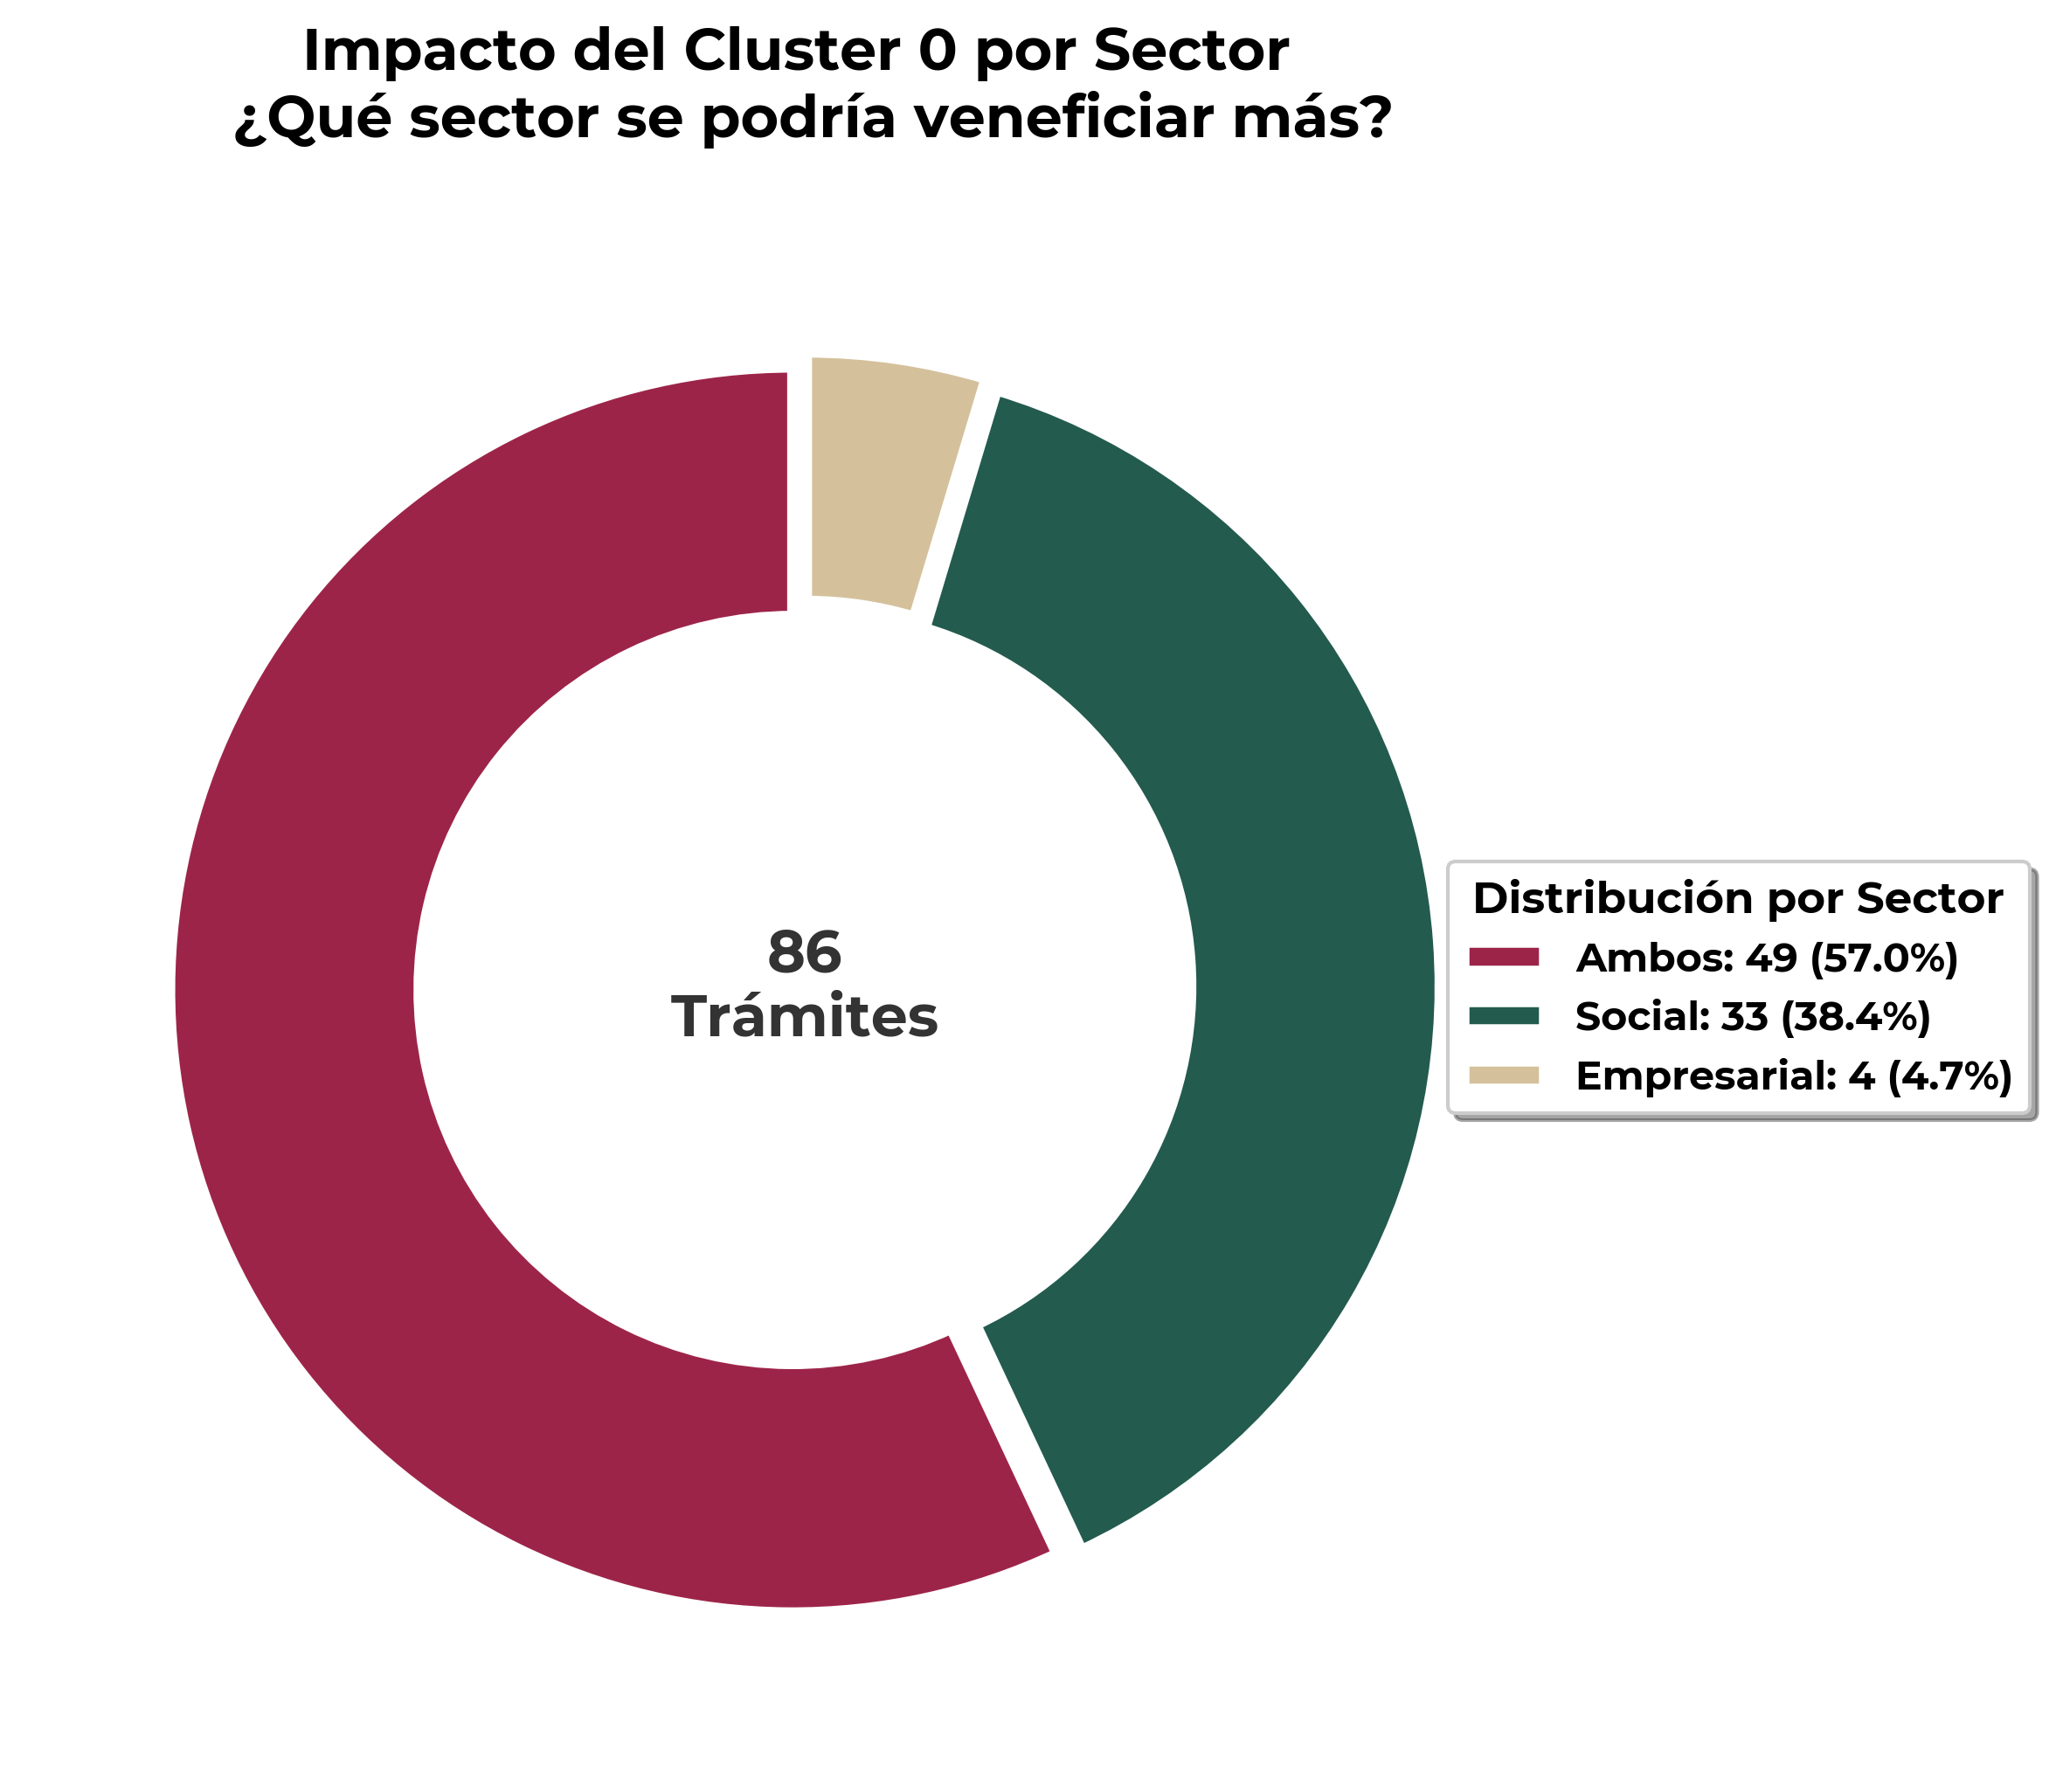

Resumen de Impacto (Cluster Cero)


,Trámites,%
TraPersona,,
Ambos,49,57.0
Social,33,38.4
Empresarial,4,4.7


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

df_critico = df_no_sep[df_no_sep['Cluster'] == 0].copy()
distribucion_persona = df_critico['TraPersona'].value_counts()
total = distribucion_persona.sum()
labels = distribucion_persona.index
counts = distribucion_persona.values

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
colores_inst = ['#9D2449', '#235B4E', '#D4C19C']

legend_labels = [f'{l}: {v} ({v/total:.1%})' for l, v in zip(labels, counts)]

wedges, texts = ax.pie(
    counts, 
    startangle=90, 
    colors=colores_inst[:len(labels)],
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 3}, 
    explode=[0.02] * len(labels) 
)

ax.text(0, 0, f"{total}\nTrámites", 
        ha='center', va='center', 
        fontsize=16, fontweight='bold', color='#333333', fontfamily='Montserrat')

ax.legend(
    wedges, 
    legend_labels,
    title="Distribución por Sector",
    loc="center left",
    bbox_to_anchor=(0.9, 0, 0.5, 1), 
    fontsize=11,
    frameon=True,
    shadow=True
)

plt.title('Impacto del Cluster 0 por Sector \n ¿Qué sector se podría veneficiar más?', 
          fontsize=16, pad=20, fontweight='bold', fontfamily='Montserrat')

plt.tight_layout()
plt.show()

print("Resumen de Impacto (Cluster Cero)")
df_resumen = pd.DataFrame({'Trámites': counts, '%': (counts/total*100).round(1)}, index=labels)
display(df_resumen)

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Cluster 1: Gratuitos Eficientes
</h4>

In [31]:
target_cluster = 1
nombre_del_grupo = "Gratuitos Eficientes"

df_total_analizado = df_no_sep.copy()
df_cluster_critico = df_no_sep[df_no_sep['Cluster'] == target_cluster].copy()

peso_en_universo = df_total_analizado["Secretaria"].value_counts(normalize=True) * 100

peso_en_cluster = df_cluster_critico["Secretaria"].value_counts(normalize=True) * 100

conteo_neto = df_cluster_critico["Secretaria"].value_counts()

comparativa = pd.DataFrame({
    'Trámites_en_Cluster_2': conteo_neto,
    '%_de_Presencia_en_Cluster': peso_en_cluster,
    '%_de_Presencia_en_Gobierno_Sin_SEP': peso_en_universo
})

comparativa = comparativa.fillna(0)
comparativa = comparativa[comparativa['Trámites_en_Cluster_2'] > 0]

comparativa['Indice_Concentracion'] = comparativa['%_de_Presencia_en_Cluster'] / comparativa['%_de_Presencia_en_Gobierno_Sin_SEP']

comparativa = comparativa.sort_values(by='Indice_Concentracion', ascending=False)

tabla_estilizada = comparativa.style.format({
    'Trámites_en_Cluster_2': '{:.0f}',
    '%_de_Presencia_en_Cluster': '{:.2f}%',
    '%_de_Presencia_en_Gobierno_Sin_SEP': '{:.2f}%',
    'Indice_Concentracion': '{:.2f}'
}).background_gradient(subset=['Indice_Concentracion'], cmap='YlOrRd')

print(f"Análisis de Concentración: Cluster {target_cluster} ({nombre_del_grupo})")
print(f"Total de trámites: {len(df_cluster_critico)}")
display(tabla_estilizada)

Análisis de Concentración: Cluster 1 (Gratuitos Eficientes)
Total de trámites: 74


,Trámites_en_Cluster_2,%_de_Presencia_en_Cluster,%_de_Presencia_en_Gobierno_Sin_SEP,Indice_Concentracion
Secretaria,,,,
Secretaría de Agricultura y Desarrollo Rural,17,22.97%,4.62%,4.97
Procuraduría General de Justicia,5,6.76%,1.70%,3.97
Secretaría de Salud,12,16.22%,5.60%,2.90
Oficialía Mayor,3,4.05%,1.46%,2.78
Secretaría de Trabajo y Previsión Social,6,8.11%,4.62%,1.75
Secretaría de Desarrollo Económico,5,6.76%,4.14%,1.63
Secretaría de Medio Ambiente y Recursos Naturales,4,5.41%,3.89%,1.39
Secretaría de Seguridad Pública,1,1.35%,1.46%,0.93
Secretaría de Gobierno,10,13.51%,26.28%,0.51


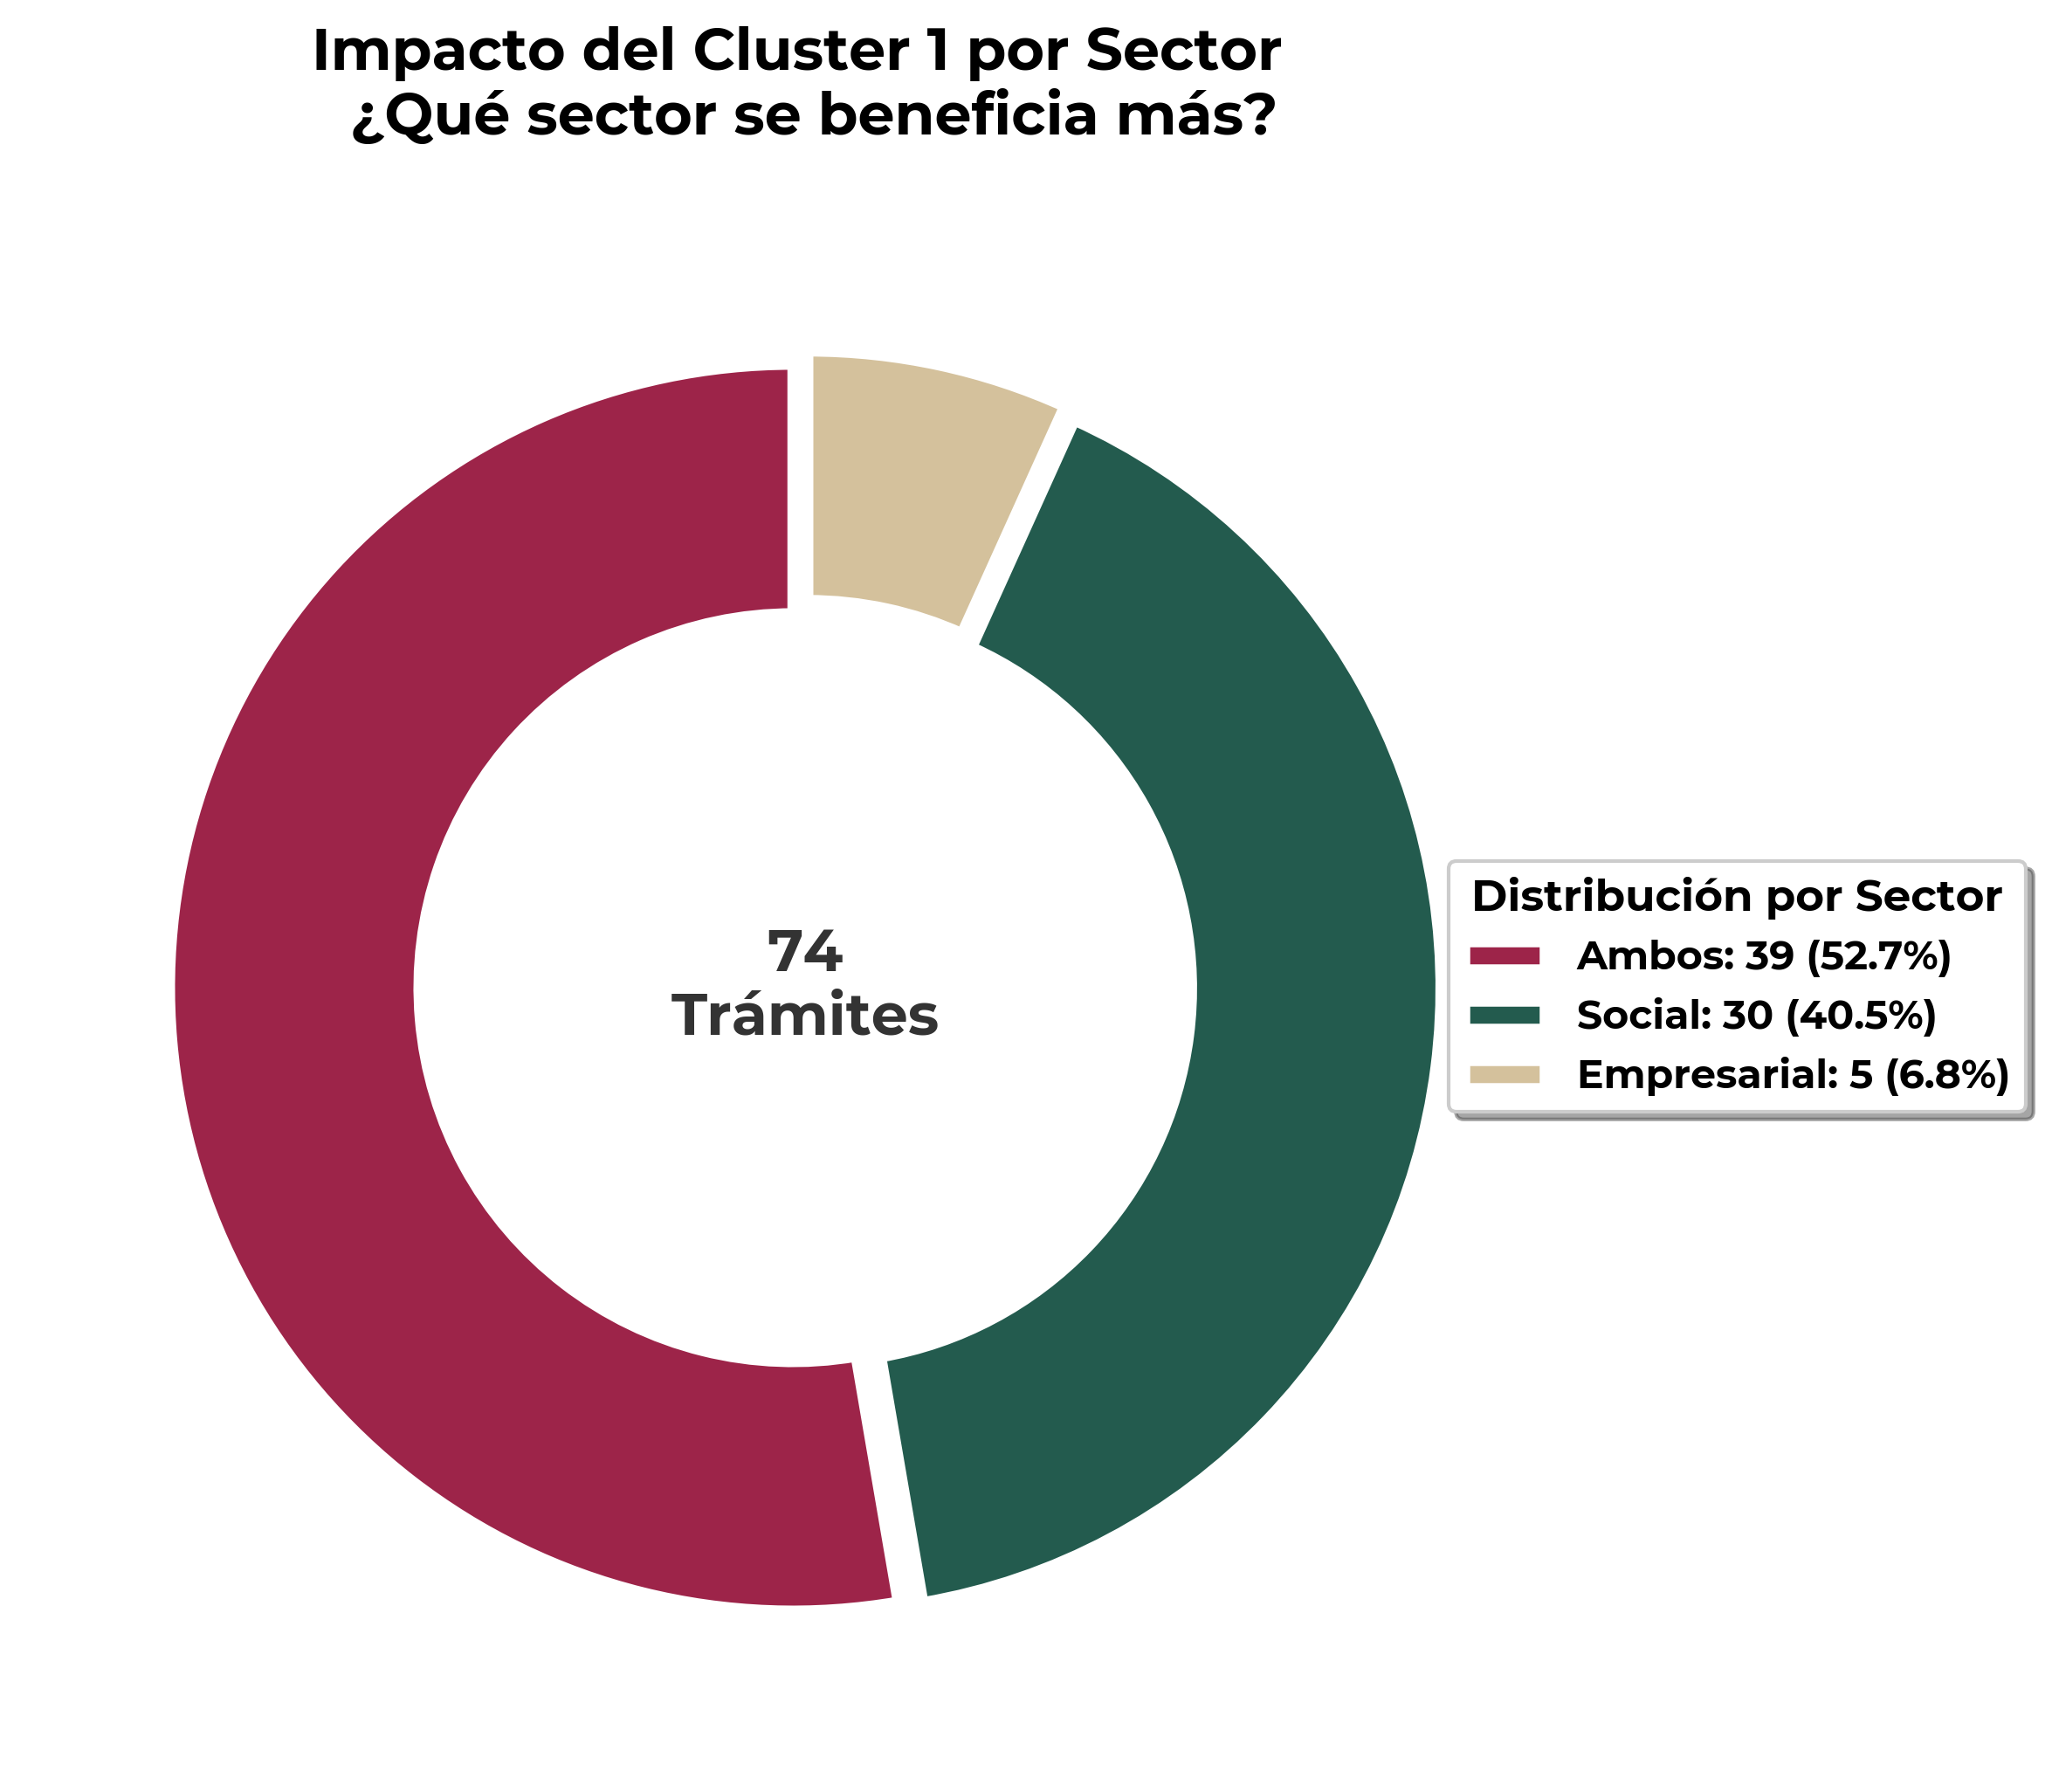

Resumen de Impacto (Cluster Uno)


,Trámites,%
TraPersona,,
Ambos,39,52.7
Social,30,40.5
Empresarial,5,6.8


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

df_critico = df_no_sep[df_no_sep['Cluster'] == 1].copy()
distribucion_persona = df_critico['TraPersona'].value_counts()
total = distribucion_persona.sum()
labels = distribucion_persona.index
counts = distribucion_persona.values

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
colores_inst = ['#9D2449', '#235B4E', '#D4C19C']

legend_labels = [f'{l}: {v} ({v/total:.1%})' for l, v in zip(labels, counts)]

wedges, texts = ax.pie(
    counts, 
    startangle=90, 
    colors=colores_inst[:len(labels)],
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 3}, 
    explode=[0.02] * len(labels) 
)

ax.text(0, 0, f"{total}\nTrámites", 
        ha='center', va='center', 
        fontsize=16, fontweight='bold', color='#333333', fontfamily='Montserrat')

ax.legend(
    wedges, 
    legend_labels,
    title="Distribución por Sector",
    loc="center left",
    bbox_to_anchor=(0.9, 0, 0.5, 1), 
    fontsize=11,
    frameon=True,
    shadow=True
)

plt.title('Impacto del Cluster 1 por Sector \n ¿Qué sector se beneficia más?', 
          fontsize=16, pad=20, fontweight='bold', fontfamily='Montserrat')

plt.tight_layout()
plt.show()

print("Resumen de Impacto (Cluster Uno)")
df_resumen = pd.DataFrame({'Trámites': counts, '%': (counts/total*100).round(1)}, index=labels)
display(df_resumen)

<h4 style="color:#98989A; font-family:'Montserrat', sans-serif; font-size:16px; font-weight:600; margin-top:15px; margin-bottom:8px;">
Cluster 2: Carga Burocrática
</h4>

In [43]:
target_cluster = 2
nombre_del_grupo = "Carga Burocrática"

df_total_analizado = df_no_sep.copy()
df_cluster_critico = df_no_sep[df_no_sep['Cluster'] == target_cluster].copy()

peso_en_universo = df_total_analizado["Secretaria"].value_counts(normalize=True) * 100

peso_en_cluster = df_cluster_critico["Secretaria"].value_counts(normalize=True) * 100

conteo_neto = df_cluster_critico["Secretaria"].value_counts()

comparativa = pd.DataFrame({
    'Trámites_en_Cluster_2': conteo_neto,
    '%_de_Presencia_en_Cluster': peso_en_cluster,
    '%_de_Presencia_en_Gobierno_Sin_SEP': peso_en_universo
})

comparativa = comparativa.fillna(0)
comparativa = comparativa[comparativa['Trámites_en_Cluster_2'] > 0]

comparativa['Indice_Concentracion'] = comparativa['%_de_Presencia_en_Cluster'] / comparativa['%_de_Presencia_en_Gobierno_Sin_SEP']

comparativa = comparativa.sort_values(by='Indice_Concentracion', ascending=False)

tabla_estilizada = comparativa.style.format({
    'Trámites_en_Cluster_2': '{:.0f}',
    '%_de_Presencia_en_Cluster': '{:.2f}%',
    '%_de_Presencia_en_Gobierno_Sin_SEP': '{:.2f}%',
    'Indice_Concentracion': '{:.2f}'
}).background_gradient(subset=['Indice_Concentracion'], cmap='YlOrRd')

print(f" Análisis de Concentración: Cluster {target_cluster} ({nombre_del_grupo})")
print(f"Total de trámites: {len(df_cluster_critico)}")
display(tabla_estilizada)

 Análisis de Concentración: Cluster 2 (Carga Burocrática)
Total de trámites: 50


,Trámites_en_Cluster_2,%_de_Presencia_en_Cluster,%_de_Presencia_en_Gobierno_Sin_SEP,Indice_Concentracion
Secretaria,,,,
Secretaría de Gobierno,38,76.00%,26.28%,2.89
Secretaría de Seguridad Pública,2,4.00%,1.46%,2.74
Procuraduría General de Justicia,1,2.00%,1.70%,1.17
Secretaría de Medio Ambiente y Recursos Naturales,2,4.00%,3.89%,1.03
Secretaría de Hacienda,6,12.00%,12.17%,0.99
Secretaría de Agricultura y Desarrollo Rural,1,2.00%,4.62%,0.43


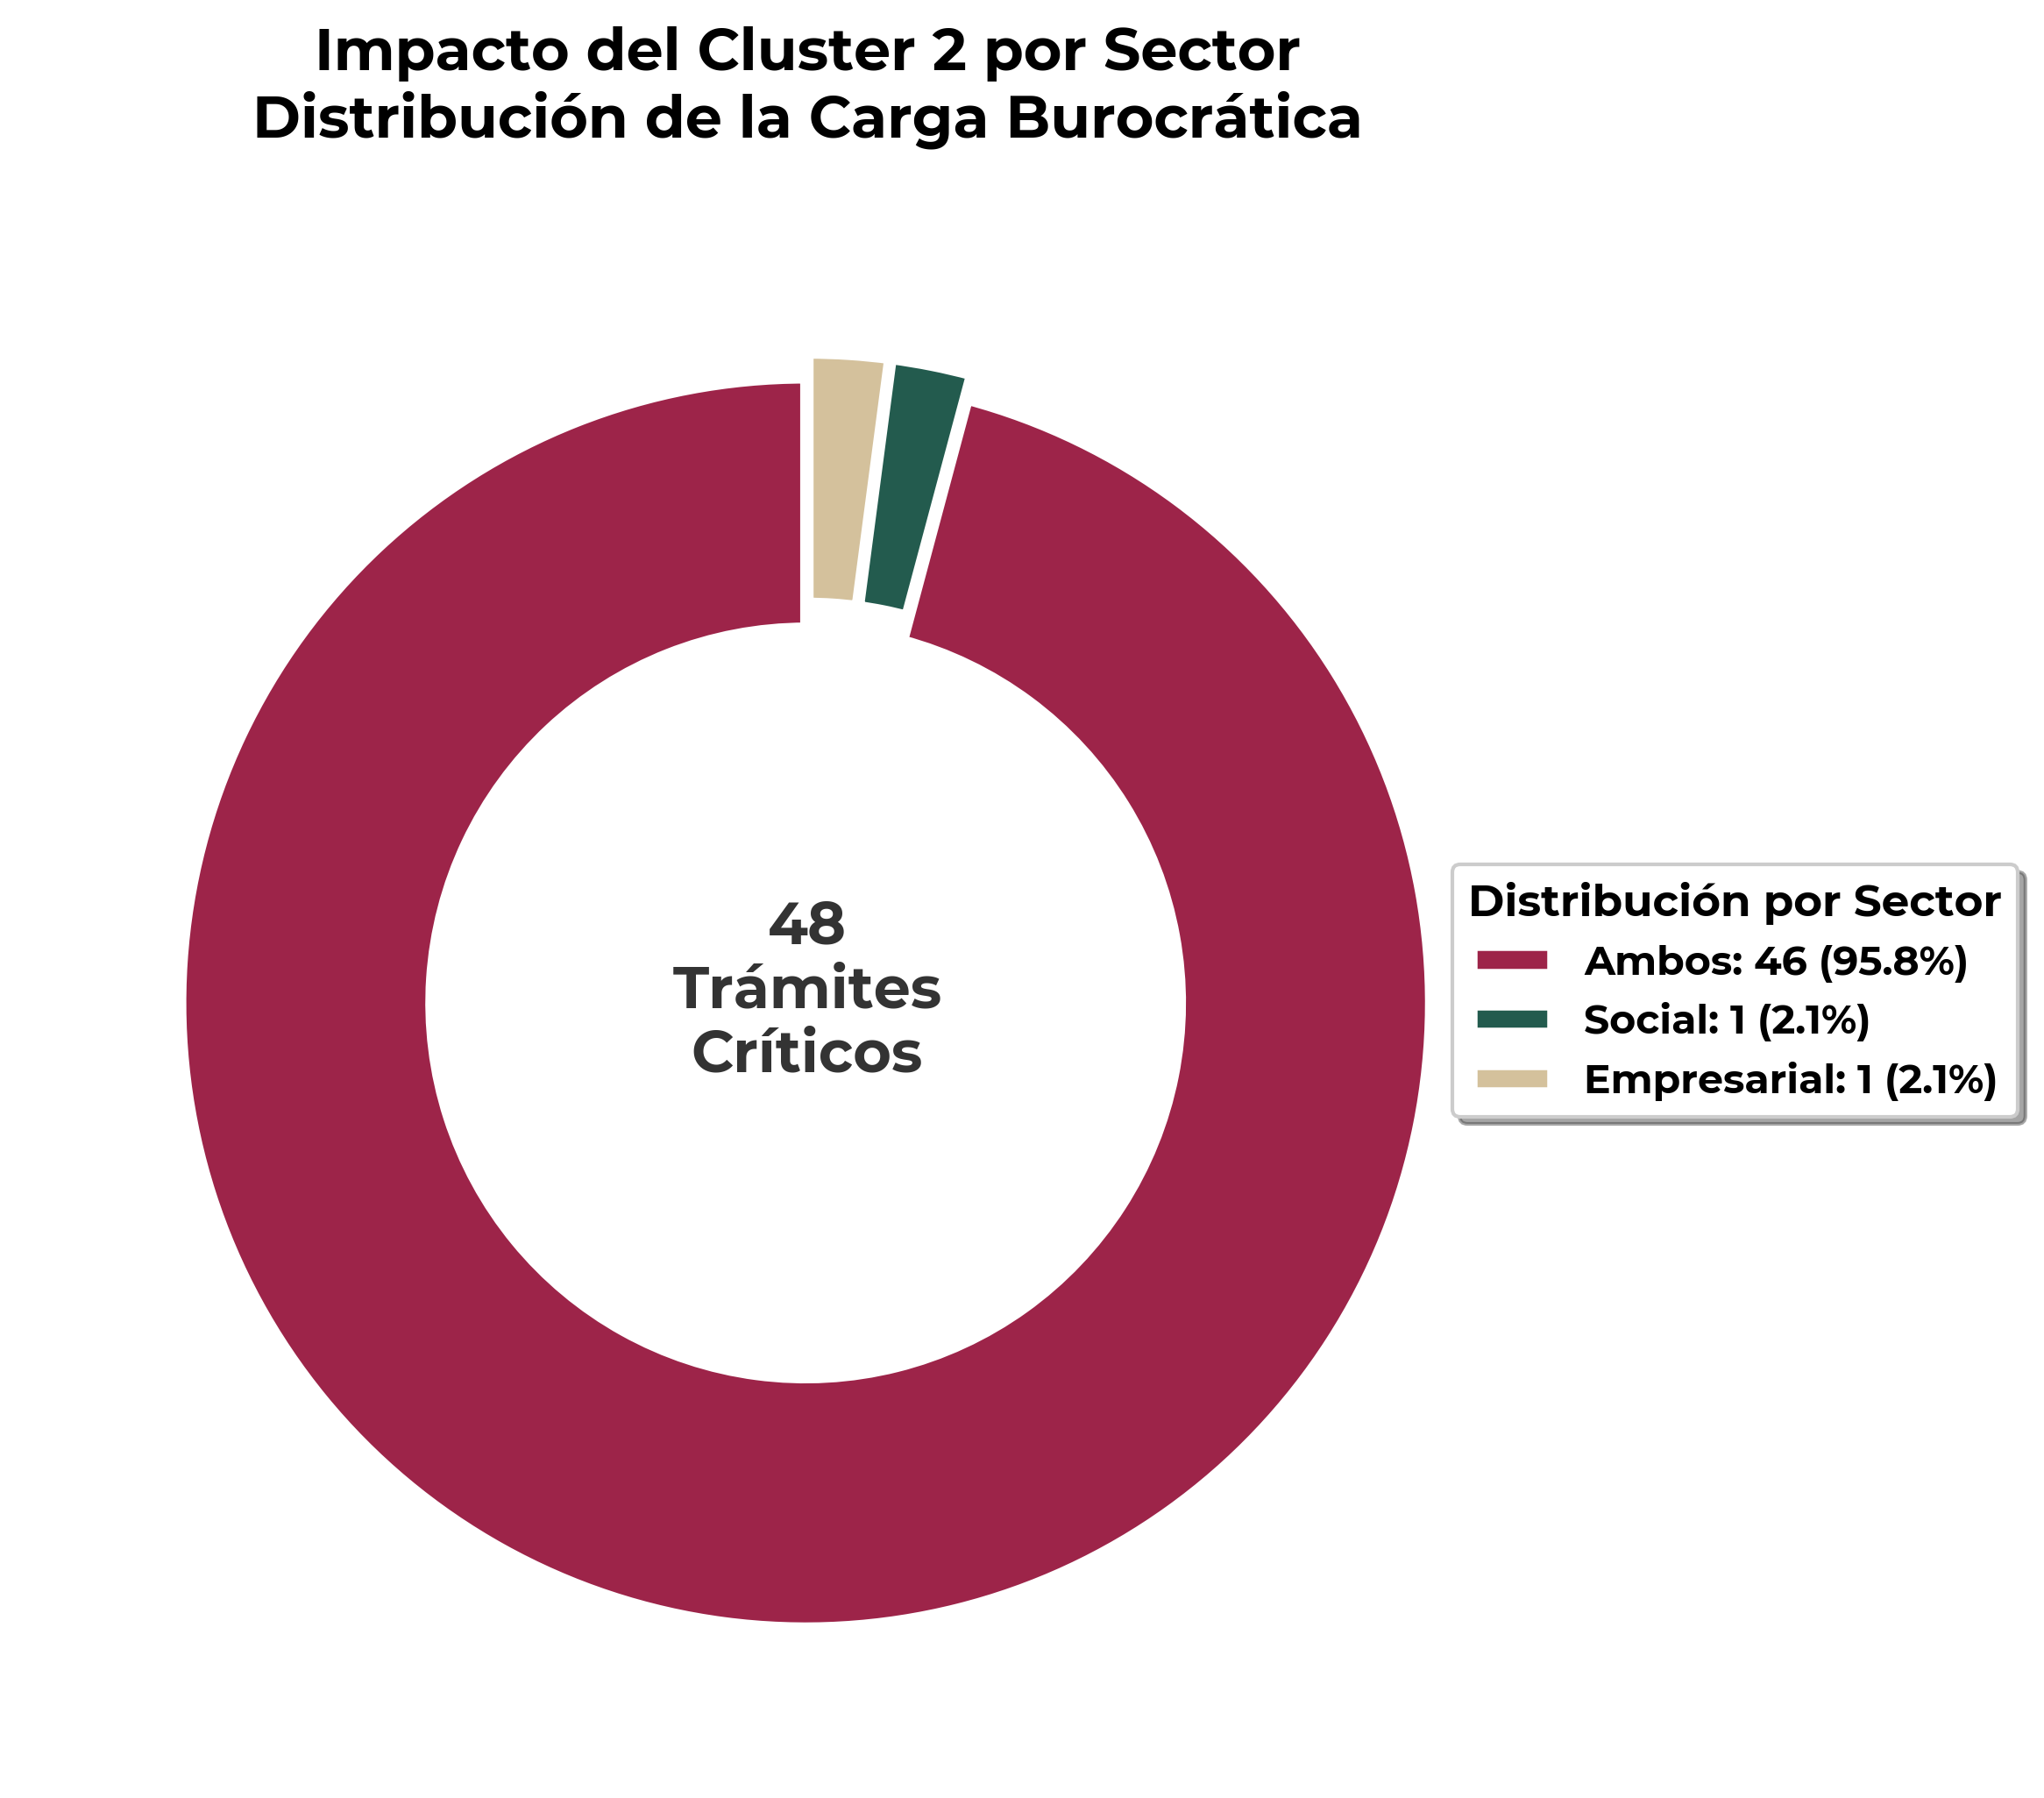

Resumen de Impacto (Cluster Crítico)


,Trámites,%
TraPersona,,
Ambos,46,95.8
Social,1,2.1
Empresarial,1,2.1


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

df_critico = df_no_sep[df_no_sep['Cluster'] == 2].copy()
distribucion_persona = df_critico['TraPersona'].value_counts()
total = distribucion_persona.sum()
labels = distribucion_persona.index
counts = distribucion_persona.values

fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
colores_inst = ['#9D2449', '#235B4E', '#D4C19C']

legend_labels = [f'{l}: {v} ({v/total:.1%})' for l, v in zip(labels, counts)]

wedges, texts = ax.pie(
    counts, 
    startangle=90, 
    colors=colores_inst[:len(labels)],
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 3}, 
    explode=[0.02] * len(labels) 
)

ax.text(0, 0, f"{total}\nTrámites\nCríticos", 
        ha='center', va='center', 
        fontsize=16, fontweight='bold', color='#333333', fontfamily='Montserrat')

ax.legend(
    wedges, 
    legend_labels,
    title="Distribución por Sector",
    loc="center left",
    bbox_to_anchor=(0.9, 0, 0.5, 1), 
    fontsize=11,
    frameon=True,
    shadow=True
)

plt.title('Impacto del Cluster 2 por Sector\nDistribución de la Carga Burocrática', 
          fontsize=16, pad=20, fontweight='bold', fontfamily='Montserrat')

plt.tight_layout()
plt.show()

print("Resumen de Impacto (Cluster Crítico)")
df_resumen = pd.DataFrame({'Trámites': counts, '%': (counts/total*100).round(1)}, index=labels)
display(df_resumen)